# Retail Product Intelligence Pipeline — v1

**Offline experimentation (Dunnhumby dataset) · designed to be reusable as production services**

## What this notebook builds

A complete **product representation and relationship intelligence pipeline**:

```
Raw Data
  → Product Representation (features)
  → Product Embeddings (metadata / behavioral / demand)
  → Candidate Generation
  → Pairwise Relationship Features
  → Unsupervised Relationship Modeling (substitution / complementary / confidence)
  → Explainability
  → Temporal Relationship Analysis
  → Visualization Dashboard
  → Exportable Production Assets (parquet + JSON)
```

## Design principles

- **No weak labels, no heuristic ground truth, no fake binary labels.** All relationship
  scoring is **unsupervised**: generative mixture models, anomaly detection, and rank-based
  scoring. Heuristics are used **only** for candidate generation / filtering (top-k nearest
  neighbors), which the pipeline explicitly distinguishes from modeling.
- **Modular functions.** Every phase is a named, reusable function (`build_product_features`,
  `build_metadata_embedding`, `generate_product_candidates`, `build_pair_features`, ...) so each
  component can later be extracted into a standalone production service.
- **Validation after every phase.** Each section ends with checks (schemas, NaN/Inf, counts,
  sanity) so failures surface at the exact phase that broke.
- **Configuration-first.** All paths, seeds, dimensions and model parameters live in a single
  `PipelineConfig` object instead of being scattered through the code.

## Mapping to production (read this first)

| Notebook phase | Future production service |
|---|---|
| Data loading layer | `DataLoader` service with schema validation |
| Product feature engineering | Offline feature store writer (parquet / Iceberg) |
| Embedding layers | Vectorization service (batch + online) |
| Embedding quality tests | Model evaluation / drift monitoring job |
| Candidate generation | Approximate nearest-neighbor service (FAISS) |
| Pair feature engineering | Feature pipeline for the relationship store |
| ML relationship modeling | Scoring service (substitution / complementary / confidence) |
| Explainability | MCP tool `explain_relationship` + LLM analyst evidence |
| Temporal analysis | Relationship drift monitoring |
| Export assets | Assets consumed by backend APIs, MCP tools, ML pipelines |

## 1. Environment and Configuration

Everything needed to run this notebook is configured here: paths, seeds, embedding
dimensions, model parameters and output directories. In production this object maps
1-to-1 to a validated YAML/JSON config consumed by the service layer.

In [1]:
# --- core imports -------------------------------------------------------
import os
import re
import sys
import json
import gc
import time
import random
import warnings
import importlib
import subprocess
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
from scipy import sparse

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import OneHotEncoder, StandardScaler, normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (12, 5)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 60)

In [2]:
def find_project_root(start: Path = None) -> Path:
    """Walk up from cwd until we find the repo's data/raw directory.

    Makes the notebook runnable from any working directory (Jupyter, nbconvert,
    or a scheduler) and mirrors how a production service locates its data root.
    """
    start = Path(start or os.environ.get("PROMOTION_INTELLIGENCE_ROOT", Path.cwd()))
    for p in [start, *start.parents]:
        if (p / "data" / "raw" / "transaction_data.csv").exists():
            return p
    return start


@dataclass(frozen=True)
class PipelineConfig:
    """Single source of truth for every pipeline parameter.

    Frozen dataclass -> cannot be mutated accidentally after construction.
    Replace with pydantic/YAML in production deployments.
    """

    # --- paths -------------------------------------------------------
    project_root: Path = None

    # --- reproducibility ---------------------------------------------
    seed: int = 42
    n_jobs: int = 4

    # --- data ---------------------------------------------------------
    total_weeks: int = 102                       # Dunnhumby observation window
    min_core_transactions: int = 20              # candidate products need >= this many txn rows
    min_core_sales: float = 10.0                 # candidate products need >= this lifetime sales

    # --- embedding dimensions -----------------------------------------
    metadata_emb_dim: int = 64
    behavioral_emb_dim: int = 64
    demand_emb_dim: int = 32
    final_emb_dim: int = 128

    # --- Word2Vec (behavioral embedding) --------------------------------
    w2v_window: int = 5
    w2v_min_count: int = 5
    w2v_sg: int = 1                              # skip-gram
    w2v_negative: int = 10
    w2v_epochs: int = 6
    w2v_sample: float = 1e-4
    max_basket_len: int = 100

    # --- candidate generation ------------------------------------------
    top_k_candidates: int = 25
    candidate_min_similarity: float = 0.55

    # --- visualization / clustering -------------------------------------
    viz_sample_size: int = 8000
    umap_sample_size: int = 5000
    umap_n_neighbors: int = 15
    umap_min_dist: float = 0.1
    kmeans_k_candidates: tuple = (10, 15, 20, 25, 30)
    hdbscan_min_cluster_size: int = 60

    # --- unsupervised relationship models --------------------------------
    gmm_n_components: int = 2
    gmm_covariance_type: str = "full"
    if_n_estimators: int = 300

    # --- temporal analysis ------------------------------------------------
    temporal_block_weeks: int = 4
    temporal_top_pairs: int = 25

    # --- explainability -----------------------------------------------------
    explain_top_pairs: int = 20
    permutation_sample: int = 1000
    permutation_repeats: int = 3

    def __post_init__(self):
        root = find_project_root()
        object.__setattr__(self, "project_root", root)
        object.__setattr__(self, "data_dir", root / "data" / "raw")
        object.__setattr__(self, "output_dir", root / "outputs" / "product_intelligence")
        object.__setattr__(self, "figures_dir", self.output_dir / "figures")


CFG = PipelineConfig()
for d in (CFG.output_dir, CFG.figures_dir):
    d.mkdir(parents=True, exist_ok=True)


def set_seed(seed: int = CFG.seed) -> None:
    """Seed numpy/random so every run reproduces the same artifacts."""
    np.random.seed(seed)
    random.seed(seed)


set_seed()
print(f"Project root : {CFG.project_root}")
print(f"Data dir     : {CFG.data_dir}")
print(f"Output dir   : {CFG.output_dir}")

Project root : /home/mhseddighi/Projects/promotion-intelligence
Data dir     : /home/mhseddighi/Projects/promotion-intelligence/data/raw
Output dir   : /home/mhseddighi/Projects/promotion-intelligence/outputs/product_intelligence


### Dependency checks

Production notebooks should fail fast with actionable messages. We check hard and
optional dependencies; optional ones can be auto-installed with the flag below.

In [3]:
REQUIRED_PACKAGES = {
    "pandas": "pandas", "numpy": "numpy", "scipy": "scipy", "sklearn": "scikit-learn",
    "matplotlib": "matplotlib", "seaborn": "seaborn",
}
OPTIONAL_PACKAGES = {
    "gensim": "gensim", "umap": "umap-learn", "hdbscan": "hdbscan",
    "faiss": "faiss-cpu", "shap": "shap", "networkx": "networkx",
}

# Set to True to let this cell pip-install any missing packages automatically.
INSTALL_MISSING_DEPS = False


def check_dependencies(install_missing: bool = False) -> pd.DataFrame:
    """Verify all required/optional packages import; optionally install missing ones."""
    rows, missing = [], []
    for module, pkg in {**REQUIRED_PACKAGES, **OPTIONAL_PACKAGES}.items():
        try:
            mod = importlib.import_module(module)
            rows.append((pkg, getattr(mod, "__version__", "unknown"), "ok"))
        except ImportError:
            rows.append((pkg, "-", "MISSING"))
            missing.append(pkg)
    status = pd.DataFrame(rows, columns=["package", "version", "status"])
    print(status.to_string(index=False))

    if missing and install_missing:
        print(f"\nInstalling missing packages: {missing}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
        return check_dependencies(install_missing=False)

    hard_missing = [p for p in missing if p in REQUIRED_PACKAGES.values()]
    if hard_missing:
        raise RuntimeError(
            f"Missing required packages: {hard_missing}. "
            f"Run: python -m pip install {' '.join(hard_missing)}"
        )
    if missing:
        print(f"\nWARNING: optional packages missing (pip install {' '.join(missing)}):")
        print("  - gensim      -> behavioral (Product2Vec) embedding")
        print("  - umap-learn  -> embedding visualization")
        print("  - hdbscan     -> density-based clustering evaluation")
        print("  - faiss-cpu   -> fast candidate generation (falls back to sklearn)")
        print("  - shap        -> model explainability")
        print("  - networkx    -> relationship graph dashboard")
    return status


deps = check_dependencies(install_missing=INSTALL_MISSING_DEPS)

     package version status
      pandas   2.3.3     ok
       numpy   2.4.6     ok
       scipy  1.15.3     ok
scikit-learn   1.6.1     ok
  matplotlib  3.11.1     ok
     seaborn  0.13.2     ok
      gensim   4.4.0     ok
  umap-learn  0.5.12     ok
     hdbscan unknown     ok
   faiss-cpu  1.15.0     ok
        shap  0.48.0     ok
    networkx   3.6.1     ok


## 2. Data Loading Layer

The Dunnhumby dataset is a set of static CSVs. Loading is wrapped in typed functions so
that the rest of the notebook never touches raw paths or dtypes again. Explicit dtypes
matter here: `transaction_data.csv` has ~2.6M rows and `causal_data.csv` has ~36.8M rows,
so naive loading wastes memory and time.

In production this layer becomes a `DataLoader` service that reads from a data lake and
validates schemas before anything else runs.

In [4]:
TX_DTYPES = {
    "household_key": "int32", "BASKET_ID": "int64", "DAY": "int16",
    "PRODUCT_ID": "int32", "QUANTITY": "int32", "SALES_VALUE": "float32",
    "STORE_ID": "int16", "RETAIL_DISC": "float32", "TRANS_TIME": "int32",
    "WEEK_NO": "int16", "COUPON_DISC": "float32", "COUPON_MATCH_DISC": "float32",
}
CAUSAL_DTYPES = {
    "PRODUCT_ID": "int32", "STORE_ID": "int16", "WEEK_NO": "int16",
    "display": "category", "mailer": "category",
}


def load_transactions(path: Path = None) -> pd.DataFrame:
    """Load basket-level transaction data (row = one product line in a basket)."""
    return pd.read_csv(path or CFG.data_dir / "transaction_data.csv", dtype=TX_DTYPES)


def load_products(path: Path = None) -> pd.DataFrame:
    """Load product master data (one row per product)."""
    return pd.read_csv(path or CFG.data_dir / "product.csv")


def load_causal_data(path: Path = None) -> pd.DataFrame:
    """Load product-store-week causal data (display / mailer promotion activity)."""
    return pd.read_csv(path or CFG.data_dir / "causal_data.csv", dtype=CAUSAL_DTYPES)


def load_campaign_table(path: Path = None) -> pd.DataFrame:
    """Load campaign -> household membership table."""
    return pd.read_csv(path or CFG.data_dir / "campaign_table.csv")


def load_campaign_desc(path: Path = None) -> pd.DataFrame:
    """Load campaign descriptions (type, start/end day)."""
    return pd.read_csv(path or CFG.data_dir / "campaign_desc.csv")


def load_all_data() -> dict:
    """Load every required Dunnhumby file into a dict of DataFrames."""
    return {
        "transactions": load_transactions(),
        "products": load_products(),
        "causal_data": load_causal_data(),
        "campaign_table": load_campaign_table(),
        "campaign_desc": load_campaign_desc(),
    }

In [5]:
data = load_all_data()
N_PRODUCTS = len(data["products"])
CAUSAL_SHAPE = data["causal_data"].shape
print("N_PRODUCTS =", N_PRODUCTS)

for name, df in data.items():
    print(f"{name:<16} shape={df.shape}")

# Free memory: we only need product-week promotion aggregates from causal_data.
tx_tmp = data["causal_data"].copy()
tx_tmp["display_on"] = tx_tmp["display"].astype(str).ne("0").astype("int8")
tx_tmp["mailer_on"] = tx_tmp["mailer"].astype(str).ne("0").astype("int8")
causal_weekly = (
    tx_tmp.groupby(["PRODUCT_ID", "WEEK_NO"], observed=True)
    [["display_on", "mailer_on"]]
    .mean()
    .rename(columns={"display_on": "display_share", "mailer_on": "mailer_share"})
    .reset_index()
)
del tx_tmp, data["causal_data"]
gc.collect()
print("\ncausal_data aggregated to product-week level:", causal_weekly.shape)
print(causal_weekly.head())

N_PRODUCTS = 92353
transactions     shape=(2595732, 12)
products         shape=(92353, 7)
causal_data      shape=(36786524, 5)
campaign_table   shape=(7208, 3)
campaign_desc    shape=(30, 4)

causal_data aggregated to product-week level: (2049187, 4)
   PRODUCT_ID  WEEK_NO  display_share  mailer_share
0       26190       52        1.00000           0.0
1       26190       70        0.12037           1.0
2       26190       71        1.00000           0.0
3       26190       72        1.00000           0.0
4       26190       73        1.00000           0.0


In [6]:
# --- inspection ---------------------------------------------------------
print("=== transactions ===")
print(data["transactions"].head(3).to_string())
print("dtypes:", dict(data["transactions"].dtypes.astype(str)))
print("missing:\n", data["transactions"].isna().sum().to_string())
print("duplicate rows:", int(data["transactions"].duplicated().sum()))
print()
print("=== products ===")
print(data["products"].head(3).to_string())
print("missing:\n", data["products"].isna().sum().to_string())
print("duplicate PRODUCT_ID:", int(data["products"]["PRODUCT_ID"].duplicated().sum()))
print()
print("=== campaign_desc ===")
print(data["campaign_desc"].head(5).to_string())
print("=== campaign_table ===")
print(data["campaign_table"].head(5).to_string())

=== transactions ===
   household_key    BASKET_ID  DAY  PRODUCT_ID  QUANTITY  SALES_VALUE  STORE_ID  RETAIL_DISC  TRANS_TIME  WEEK_NO  COUPON_DISC  COUPON_MATCH_DISC
0           2375  26984851472    1     1004906         1         1.39       364         -0.6        1631        1          0.0                0.0
1           2375  26984851472    1     1033142         1         0.82       364          0.0        1631        1          0.0                0.0
2           2375  26984851472    1     1036325         1         0.99       364         -0.3        1631        1          0.0                0.0
dtypes: {'household_key': 'int32', 'BASKET_ID': 'int64', 'DAY': 'int16', 'PRODUCT_ID': 'int32', 'QUANTITY': 'int32', 'SALES_VALUE': 'float32', 'STORE_ID': 'int16', 'RETAIL_DISC': 'float32', 'TRANS_TIME': 'int32', 'WEEK_NO': 'int16', 'COUPON_DISC': 'float32', 'COUPON_MATCH_DISC': 'float32'}
missing:
 household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QU

In [7]:
# --- validation: data loading works ------------------------------------
def validate_data_loading(data: dict, causal_weekly: pd.DataFrame) -> None:
    required_files = ["transaction_data.csv", "product.csv", "causal_data.csv",
                      "campaign_table.csv", "campaign_desc.csv"]
    missing_files = [f for f in required_files if not (CFG.data_dir / f).exists()]
    assert not missing_files, f"Missing raw files: {missing_files}"

    assert data["transactions"].shape[0] > 1_000_000, "transactions too small"
    assert data["transactions"].shape[1] == 12, "transactions schema changed"
    assert data["products"].shape[0] > 90_000, "product table too small"
    assert data["products"].shape[1] == 7, f"unexpected product table {data['products'].shape}"
    assert CAUSAL_SHAPE[0] > 10_000_000, "causal data too small"
    assert data["campaign_table"].shape[0] > 1000
    assert data["campaign_desc"].shape[0] > 10

    for key_col in ["PRODUCT_ID", "BASKET_ID"]:
        assert data["transactions"][key_col].notna().all(), f"NaN in {key_col}"
    assert data["products"]["PRODUCT_ID"].is_unique, "duplicate PRODUCT_ID in product.csv"
    assert causal_weekly.shape[0] > 1_000_000, "causal aggregation failed"
    assert causal_weekly[["display_share", "mailer_share"]].isna().sum().sum() == 0

    # every sold product must exist in the product master
    sold = set(data["transactions"]["PRODUCT_ID"].unique())
    master = set(data["products"]["PRODUCT_ID"].unique())
    orphans = sold - master
    assert not orphans, f"{len(orphans)} sold products missing from product.csv"

    print("PASS: data loading validated")
    print(f"  transactions rows     : {data['transactions'].shape[0]:,}")
    print(f"  products              : {data['products'].shape[0]:,}")
    print(f"  causal rows           : {CAUSAL_SHAPE[0]:,}")
    print(f"  causal product-weeks  : {causal_weekly.shape[0]:,}")
    print(f"  campaign table rows   : {data['campaign_table'].shape[0]:,}")
    print(f"  campaign desc rows    : {data['campaign_desc'].shape[0]:,}")


validate_data_loading(data, causal_weekly)

PASS: data loading validated
  transactions rows     : 2,595,732
  products              : 92,353
  causal rows           : 36,786,524
  causal product-weeks  : 2,049,187
  campaign table rows   : 7,208
  campaign desc rows    : 30


## 3. Product Feature Engineering Layer

`build_product_features()` turns raw transactions + product master + promotion calendar
into one row per product with three feature groups:

- **Metadata** — department, commodity, subcommodity, brand, manufacturer, package size.
- **Sales behavior** — total sales, quantity, transaction count, customer count, store
  coverage, purchase frequency, average price, discount and promotion statistics.
- **Demand behavior** — sales variance, volatility (CV), zero-sales ratio, sales
  frequency, trend statistics, seasonality indicators.

These features are the "product representation" consumed by every downstream phase.
In production this becomes the offline feature store writer for a product catalog.

In [8]:
def build_product_features(
    transactions: pd.DataFrame,
    products: pd.DataFrame,
    causal_weekly: pd.DataFrame,
    total_weeks: int = None,
) -> pd.DataFrame:
    """Build one row per product with metadata, sales-behavior and demand-behavior features."""
    total_weeks = total_weeks or CFG.total_weeks
    t0 = time.time()

    feats = products.copy()
    meta_cols = ["DEPARTMENT", "COMMODITY_DESC", "SUB_COMMODITY_DESC", "BRAND", "MANUFACTURER"]
    for col in meta_cols:
        feats[col] = feats[col].fillna("UNKNOWN").astype(str)

    # --- metadata: package size (first numeric token, e.g. "22 LB" -> 22) ----
    size_raw = feats["CURR_SIZE_OF_PRODUCT"].astype(str).str.extract(r"(\d+(?:\.\d+)?)")
    feats["PACKAGE_SIZE_NUM"] = pd.to_numeric(size_raw[0], errors="coerce").fillna(0.0)
    feats = feats.drop(columns=["CURR_SIZE_OF_PRODUCT"])

    # --- sales behavior -------------------------------------------------------
    tx = transactions.copy()
    discount = np.maximum(0.0, -(tx["RETAIL_DISC"] + tx["COUPON_DISC"]))
    tx["discount"] = discount
    tx["gross_value"] = tx["SALES_VALUE"] + discount

    agg = (
        tx.groupby("PRODUCT_ID", as_index=False)
        .agg(
            total_sales=("SALES_VALUE", "sum"),
            total_quantity=("QUANTITY", "sum"),
            total_gross=("gross_value", "sum"),
            total_discount=("discount", "sum"),
            n_transactions=("PRODUCT_ID", "size"),
            n_baskets=("BASKET_ID", "nunique"),
            n_customers=("household_key", "nunique"),
            n_stores=("STORE_ID", "nunique"),
            first_day=("DAY", "min"),
            last_day=("DAY", "max"),
        )
    )
    n_stores_total = float(transactions["STORE_ID"].nunique())
    agg["avg_price"] = agg["total_sales"] / agg["total_quantity"].replace(0, np.nan)
    agg["discount_rate"] = agg["total_discount"] / agg["total_gross"].replace(0, np.nan)
    active_days = (agg["last_day"] - agg["first_day"] + 1).replace(0, np.nan)
    agg["purchase_frequency"] = agg["n_transactions"] / active_days  # transactions per active day
    agg["store_coverage"] = agg["n_stores"] / n_stores_total

    # unit-price dispersion (only lines with positive quantity)
    up = tx[tx["QUANTITY"] > 0].copy()
    up["unit_price"] = up["SALES_VALUE"] / up["QUANTITY"]
    price_stats = up.groupby("PRODUCT_ID", as_index=False).agg(
        unit_price_mean=("unit_price", "mean"),
        unit_price_std=("unit_price", "std"),
    )

    # --- promotion statistics (product-week display/mailer exposure) ----------
    cw = causal_weekly.copy()
    cw["promo_active"] = (cw["display_share"] > 0) | (cw["mailer_share"] > 0)
    promo = cw.groupby("PRODUCT_ID", as_index=False).agg(
        promo_weeks=("promo_active", "sum"),
        display_share=("display_share", "mean"),
        mailer_share=("mailer_share", "mean"),
        display_intensity=("display_share", "max"),
    )

    # --- demand behavior (weekly sales dynamics) -------------------------------
    weekly = (
        tx.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)["SALES_VALUE"].sum()
    )
    pivot = weekly.pivot(index="PRODUCT_ID", columns="WEEK_NO", values="SALES_VALUE")
    pivot = pivot.reindex(index=feats["PRODUCT_ID"], columns=range(1, total_weeks + 1), fill_value=0.0)
    W = pivot.fillna(0.0).to_numpy(dtype=np.float32)           # (n_products, total_weeks)
    week_axis = np.arange(total_weeks, dtype=np.float32)

    mean_w = W.mean(axis=1)
    std_w = W.std(axis=1)
    logW = np.log1p(W)
    centered = logW - logW.mean(axis=1, keepdims=True)
    slope_denom = ((week_axis - week_axis.mean()) ** 2).sum()
    demand = pd.DataFrame({"PRODUCT_ID": pivot.index.to_numpy()})
    demand["sales_variance"] = W.var(axis=1)
    demand["sales_std"] = std_w
    demand["volatility"] = np.divide(std_w, mean_w, out=np.zeros_like(std_w), where=mean_w > 0)
    demand["zero_sales_ratio"] = (W == 0).mean(axis=1)
    demand["sales_frequency"] = (W > 0).mean(axis=1)
    demand["trend_slope"] = (centered * (week_axis - week_axis.mean())).sum(axis=1) / slope_denom
    top4 = np.sort(W, axis=1)[:, -4:]
    total_w = W.sum(axis=1)
    demand["seasonality_index"] = top4.sum(axis=1) / np.clip(total_w, 1e-6, None)
    demand["peak_week_share"] = top4[:, -1] / np.clip(total_w, 1e-6, None)

    # --- merge everything -------------------------------------------------------
    result = feats.merge(agg, on="PRODUCT_ID", how="left")
    result = result.merge(price_stats, on="PRODUCT_ID", how="left")
    result = result.merge(promo, on="PRODUCT_ID", how="left")
    result = result.merge(demand, on="PRODUCT_ID", how="left")

    num_cols = [c for c in result.columns if c not in ("PRODUCT_ID", *meta_cols)]
    for c in num_cols:
        result[c] = result[c].fillna(0.0)

    result["has_sales"] = (result["n_transactions"] > 0).astype("int8")
    result["log_total_sales"] = np.log1p(result["total_sales"])
    result["log_avg_price"] = np.log1p(result["avg_price"].clip(lower=0))

    print(f"build_product_features: {result.shape} in {time.time() - t0:.1f}s")
    return result


product_features = build_product_features(data["transactions"], data["products"], causal_weekly)
product_features.head(3)

build_product_features: (92353, 38) in 1.4s


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,PACKAGE_SIZE_NUM,total_sales,total_quantity,total_gross,total_discount,n_transactions,n_baskets,n_customers,n_stores,first_day,last_day,avg_price,discount_rate,purchase_frequency,store_coverage,unit_price_mean,unit_price_std,promo_weeks,display_share,mailer_share,display_intensity,sales_variance,sales_std,volatility,zero_sales_ratio,sales_frequency,trend_slope,seasonality_index,peak_week_share,has_sales,log_total_sales,log_avg_price
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22.0,20.940001,6.0,20.940001,0.0,3.0,3.0,3.0,3.0,157.0,410.0,3.49,0.0,0.011811,0.005155,3.49,0.0,0.0,0.0,0.0,0.0,2.107284,1.451649,7.071068,0.970588,0.029412,-0.000518,1.0,0.666667,1,3.088311,1.501853
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,0.0,0.990000,1.0,0.990000,0.0,1.0,1.0,1.0,1.0,250.0,250.0,0.99,0.0,1.000000,0.001718,0.99,0.0,0.0,0.0,0.0,0.0,0.009515,0.097543,10.049873,0.990196,0.009804,-0.000121,1.0,1.000000,1,0.688135,0.688135
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,0.0,1.590000,1.0,1.590000,0.0,1.0,1.0,1.0,1.0,458.0,458.0,1.59,0.0,1.000000,0.001718,1.59,0.0,0.0,0.0,0.0,0.0,0.024542,0.156660,10.049874,0.990196,0.009804,0.000156,1.0,1.000000,1,0.951658,0.951658


In [9]:
product_features.to_parquet(CFG.output_dir / "product_features.parquet", index=False)
print("saved:", CFG.output_dir / "product_features.parquet")

saved: /home/mhseddighi/Projects/promotion-intelligence/outputs/product_intelligence/product_features.parquet


In [10]:
# --- validation: feature generation works ---------------------------------
def validate_product_features(df: pd.DataFrame, expected_n: int) -> None:
    assert df.shape[0] == expected_n, f"expected {expected_n} products, got {df.shape[0]}"
    assert df["PRODUCT_ID"].is_unique, "duplicate PRODUCT_ID"
    assert df["has_sales"].sum() > 0.8 * expected_n, "too many products without sales"

    numeric = df.select_dtypes(include=[np.number])
    assert numeric.isna().sum().sum() == 0, "NaN values in numeric features"
    assert np.isfinite(numeric.to_numpy()).all(), "Inf values in numeric features"
    assert (df["total_sales"] >= 0).all(), "negative sales"
    assert (df["total_quantity"] >= 0).all(), "negative quantity"
    assert df["zero_sales_ratio"].between(0, 1).all()
    assert df["sales_frequency"].between(0, 1).all()
    assert df["avg_price"][df["has_sales"] == 1].min() >= 0, "negative price for sold product"

    reloaded = pd.read_parquet(CFG.output_dir / "product_features.parquet")
    pd.testing.assert_frame_equal(reloaded, df)
    print("PASS: product features validated")
    print(f"  products with sales : {int(df['has_sales'].sum()):,}")
    print(f"  products, total     : {df.shape[0]:,}")
    print(f"  numeric NaN/Inf     : 0")
    print("  feature distributions:")
    print(df[["total_sales", "n_transactions", "n_customers", "avg_price",
              "volatility", "zero_sales_ratio", "sales_frequency", "trend_slope"]]
          .describe().T[["mean", "std", "min", "50%", "max"]].round(3).to_string())


validate_product_features(product_features, N_PRODUCTS)

PASS: product features validated
  products with sales : 92,339
  products, total     : 92,353
  numeric NaN/Inf     : 0
  feature distributions:
                    mean       std    min     50%         max
total_sales       87.246  1722.689  0.000  10.890  503867.125
n_transactions    28.107   191.947  0.000   3.000   29778.000
n_customers       15.175    47.300  0.000   2.000    2069.000
avg_price          3.948     5.607  0.000   2.690     499.990
volatility         6.293     3.375  0.000   6.666      10.050
zero_sales_ratio   0.886     0.196  0.000   0.971       1.000
sales_frequency    0.114     0.196  0.000   0.029       1.000
trend_slope        0.001     0.004 -0.054   0.000       0.057


## 4. Product Embedding Layer

Three complementary views of every product, each capturing a different signal:

1. **Metadata embedding** — what the product *is* (catalog attributes).
2. **Behavioral embedding** — how the product *behaves* in baskets (Product2Vec).
3. **Demand embedding** — how demand for the product *evolves over time*.

The final embedding combines all three. In production these become separate vectorization
services that can be versioned, A/B tested, and served from a vector database.

### 4.1 Metadata Embedding

Categorical catalog attributes are one-hot encoded (rare categories collapsed) and reduced
with truncated SVD; continuous attributes are standardized. The result is L2-normalized so
cosine similarity is a proper dot product. A learned alternative (embedding lookup trained
on attribute sequences) is a documented production upgrade.

In [11]:
def l2_normalize(M: np.ndarray) -> np.ndarray:
    """L2-normalize rows; rows with negligible norm become exact zeros (no NaN, no drift)."""
    M = np.asarray(M, dtype=np.float32)
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    return np.divide(M, norms, out=np.zeros_like(M), where=norms > 1e-12)


def build_metadata_embedding(products: pd.DataFrame, product_features: pd.DataFrame) -> np.ndarray:
    """Embed products from catalog metadata (one-hot + SVD, L2-normalized)."""
    t0 = time.time()
    cat_cols = ["DEPARTMENT", "COMMODITY_DESC", "SUB_COMMODITY_DESC", "BRAND", "MANUFACTURER"]
    X_cat = products[cat_cols].fillna("UNKNOWN").astype(str)

    ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=True)
    X_ohe = ohe.fit_transform(X_cat)

    n_num = 4
    svd = TruncatedSVD(n_components=CFG.metadata_emb_dim - n_num, random_state=CFG.seed)
    X_svd = svd.fit_transform(X_ohe)

    num_df = product_features[["log_total_sales", "log_avg_price", "PACKAGE_SIZE_NUM", "display_share"]]
    num = StandardScaler().fit_transform(num_df.fillna(0.0))

    E = l2_normalize(np.hstack([X_svd, num]))
    print(f"build_metadata_embedding: {E.shape} in {time.time() - t0:.1f}s")
    return E


metadata_embedding = build_metadata_embedding(data["products"], product_features)
print("sample row norm:", np.linalg.norm(metadata_embedding[:5], axis=1))

build_metadata_embedding: (92353, 64) in 2.6s
sample row norm: [1.         1.         0.99999994 0.99999994 1.        ]


In [12]:
# --- validation: metadata embedding --------------------------------------
def validate_metadata_embedding(E: np.ndarray, expected_n: int) -> None:
    assert E.shape == (expected_n, CFG.metadata_emb_dim), f"unexpected shape {E.shape}"
    assert not np.isnan(E).any(), "NaN in metadata embedding"
    assert np.isfinite(E).all(), "Inf in metadata embedding"
    norms = np.linalg.norm(E, axis=1)
    assert np.allclose(norms[norms > 0], 1.0, atol=1e-4), "non-unit L2 norm"

    # sanity: same-commodity pairs are more similar than random pairs
    rng = np.random.default_rng(CFG.seed)
    prods = product_features[product_features["COMMODITY_DESC"] != "UNKNOWN"]
    commodities = prods["COMMODITY_DESC"].value_counts()
    commodities = commodities[commodities >= 20].index
    pos = {int(p): i for i, p in enumerate(product_features["PRODUCT_ID"])}
    same, diff = [], []
    for _ in range(1200):
        com = rng.choice(commodities)
        members = prods[prods["COMMODITY_DESC"] == com]["PRODUCT_ID"].to_numpy()
        if len(members) < 2:
            continue
        a, b = rng.choice(members, 2, replace=False)
        same.append(float(E[pos[int(a)]] @ E[pos[int(b)]]))
        c1, c2 = rng.choice(prods["PRODUCT_ID"].to_numpy(), 2, replace=False)
        diff.append(float(E[pos[int(c1)]] @ E[pos[int(c2)]]))
    same_sim, diff_sim = float(np.mean(same)), float(np.mean(diff))
    assert same_sim > diff_sim, f"metadata sanity failed: same={same_sim:.3f} <= diff={diff_sim:.3f}"
    print("PASS: metadata embedding validated")
    print(f"  mean same-commodity cosine similarity : {same_sim:.3f}")
    print(f"  mean random-pair   cosine similarity : {diff_sim:.3f}")


validate_metadata_embedding(metadata_embedding, N_PRODUCTS)

PASS: metadata embedding validated
  mean same-commodity cosine similarity : 0.559
  mean random-pair   cosine similarity : 0.211


### 4.2 Behavioral Product Embedding (Product2Vec)

Baskets are treated as sentences and products as words, then a skip-gram Word2Vec model is
trained over the full basket history. Products that co-occur in baskets (and in similar
basket contexts) land close together. Products below `min_count` get a zero vector here;
the final combined embedding still covers them via metadata + demand views.

In [13]:
def build_behavioral_embedding(
    transactions: pd.DataFrame,
    product_ids: np.ndarray,
) -> tuple:
    """Train Product2Vec (Word2Vec skip-gram) over baskets; return matrix + model."""
    from gensim.models import Word2Vec

    t0 = time.time()
    baskets = transactions.groupby("BASKET_ID")["PRODUCT_ID"].agg(list)
    baskets = baskets.apply(lambda b: b[: CFG.max_basket_len])          # cap very large baskets

    model = Word2Vec(
        baskets.tolist(),
        vector_size=CFG.behavioral_emb_dim,
        window=CFG.w2v_window,
        min_count=CFG.w2v_min_count,
        sg=CFG.w2v_sg,
        negative=CFG.w2v_negative,
        epochs=CFG.w2v_epochs,
        sample=CFG.w2v_sample,
        workers=CFG.n_jobs,
        seed=CFG.seed,
    )

    pos_map = {int(p): i for i, p in enumerate(product_ids)}
    E = np.zeros((len(product_ids), CFG.behavioral_emb_dim), dtype=np.float32)
    for key in model.wv.key_to_index:
        idx = pos_map.get(int(key))
        if idx is not None:
            E[idx] = model.wv[key]
    E = l2_normalize(E)

    coverage = (np.linalg.norm(E, axis=1) > 0).mean()
    print(f"build_behavioral_embedding: {E.shape} in {time.time() - t0:.1f}s "
          f"(vocab={len(model.wv)}, coverage={coverage:.1%})")
    return E, model


behavioral_embedding, w2v_model = build_behavioral_embedding(data["transactions"], product_features["PRODUCT_ID"].to_numpy())

build_behavioral_embedding: (92353, 64) in 23.8s (vocab=37153, coverage=40.2%)


In [14]:
# --- validation: behavioral embedding --------------------------------------
def validate_behavioral_embedding(E: np.ndarray, expected_n: int) -> None:
    assert E.shape == (expected_n, CFG.behavioral_emb_dim), f"unexpected shape {E.shape}"
    assert not np.isnan(E).any(), "NaN in behavioral embedding"
    assert np.isfinite(E).all(), "Inf in behavioral embedding"
    norms = np.linalg.norm(E, axis=1)
    assert np.allclose(norms[norms > 0], 1.0, atol=1e-4)

    # sanity: top similar product of a popular product should be in a nearby category
    probe = product_features.nlargest(1, "total_sales")["PRODUCT_ID"].iloc[0]
    probe_idx = int(np.flatnonzero(product_features["PRODUCT_ID"] == probe)[0])
    sims = E @ E[probe_idx]
    top = np.argsort(-sims)[1:6]
    print("PASS: behavioral embedding validated")
    print(f"  probe product        : {probe} ({product_features.loc[product_features['PRODUCT_ID']==probe,'COMMODITY_DESC'].iloc[0]})")
    print("  top-5 neighbors:")
    for i in top:
        pid = product_features["PRODUCT_ID"].iloc[i]
        com = product_features.loc[product_features["PRODUCT_ID"] == pid, "COMMODITY_DESC"].iloc[0]
        print(f"    {int(pid):>8} sim={sims[i]:.3f}  {com}")
    # top neighbor must be a clear outlier vs the global similarity distribution
    assert sims[top[0]] > sims.mean() + 2.5 * sims.std(), "top behavioral neighbor not significantly similar"


validate_behavioral_embedding(behavioral_embedding, N_PRODUCTS)

PASS: behavioral embedding validated
  probe product        : 6534178 (COUPON/MISC ITEMS)
  top-5 neighbors:
     6533765 sim=0.947  FUEL
     7433029 sim=0.933  TOBACCO OTHER
     1055831 sim=0.891  CIGARETTES
     1086119 sim=0.877  CIGARETTES
      967612 sim=0.871  BAKED SWEET GOODS


### 4.3 Demand Pattern Embedding

Each product's weekly sales history is embedded with truncated SVD, capturing the shape of
demand: level, seasonality and trend. Products whose demand rises and falls together are
near each other — the key signal for substitution and complementary relationships.

In [15]:
def build_demand_embedding(
    transactions: pd.DataFrame,
    product_ids: np.ndarray,
    total_weeks: int = None,
) -> np.ndarray:
    """Embed products from their weekly sales patterns (log1p + SVD, L2-normalized)."""
    t0 = time.time()
    total_weeks = total_weeks or CFG.total_weeks
    weekly = transactions.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)["SALES_VALUE"].sum()
    pivot = weekly.pivot(index="PRODUCT_ID", columns="WEEK_NO", values="SALES_VALUE")
    pivot = pivot.reindex(index=product_ids, columns=range(1, total_weeks + 1), fill_value=0.0)
    W = np.log1p(pivot.fillna(0.0).to_numpy(dtype=np.float32))

    svd = TruncatedSVD(n_components=CFG.demand_emb_dim, random_state=CFG.seed)
    E = l2_normalize(svd.fit_transform(W))
    print(f"build_demand_embedding: {E.shape} in {time.time() - t0:.1f}s")
    return E


demand_embedding = build_demand_embedding(data["transactions"], product_features["PRODUCT_ID"].to_numpy())

build_demand_embedding: (92353, 32) in 2.5s


In [16]:
# --- validation: demand embedding ------------------------------------------
def validate_demand_embedding(E: np.ndarray, expected_n: int) -> None:
    assert E.shape == (expected_n, CFG.demand_emb_dim), f"unexpected shape {E.shape}"
    assert not np.isnan(E).any(), "NaN in demand embedding"
    assert np.isfinite(E).all(), "Inf in demand embedding"
    norms = np.linalg.norm(E, axis=1)
    assert np.allclose(norms[norms > 0], 1.0, atol=1e-4)

    # sanity: products with highly correlated weekly sales should be near each other
    rng = np.random.default_rng(CFG.seed)
    sold = product_features[product_features["has_sales"] == 1]["PRODUCT_ID"].to_numpy()
    a = int(rng.choice(sold))
    weekly = (data["transactions"]
              .groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)["SALES_VALUE"].sum()
              .pivot(index="PRODUCT_ID", columns="WEEK_NO", values="SALES_VALUE")
              .fillna(0.0))
    wa = weekly.loc[a].to_numpy(dtype=np.float32)
    corrs = weekly.apply(lambda r: np.corrcoef(wa, r.to_numpy(dtype=np.float32))[0, 1]
                         if r.var() > 0 else 0.0, axis=1).fillna(0.0)
    best = int(corrs.nlargest(2).index[1])           # highest-correlated *other* product
    ia = int(np.flatnonzero(product_features["PRODUCT_ID"] == a)[0])
    ib = int(np.flatnonzero(product_features["PRODUCT_ID"] == best)[0])
    sim_ab = float(E[ia] @ E[ib])
    pos = {int(p): i for i, p in enumerate(product_features["PRODUCT_ID"])}
    sold_pos = np.array([pos[int(p)] for p in sold])
    random_pairs = rng.integers(0, len(sold), size=(300, 2))
    rand_sims = (E[sold_pos[random_pairs[:, 0]]] * E[sold_pos[random_pairs[:, 1]]]).sum(axis=1).mean()
    assert sim_ab > rand_sims, f"demand sanity failed: {sim_ab:.3f} <= {rand_sims:.3f}"
    print("PASS: demand embedding validated")
    print(f"  probe {a} vs highest-correlated product {best}: cosine={sim_ab:.3f} (random avg={rand_sims:.3f})")


validate_demand_embedding(demand_embedding, N_PRODUCTS)

PASS: demand embedding validated
  probe 839880 vs highest-correlated product 915379: cosine=0.862 (random avg=0.106)


### 4.4 Combine Embeddings

The three views are concatenated, projected to the final dimension with PCA, and
L2-normalized. This yields `final_product_embedding` — one vector per product that any
downstream service (search, recommendation, relationship scoring) can consume directly.

In [17]:
def combine_embeddings(
    metadata: np.ndarray,
    behavioral: np.ndarray,
    demand: np.ndarray,
    product_ids: np.ndarray,
    final_dim: int = None,
) -> tuple:
    """Concatenate all embedding views, reduce dimensions, L2-normalize."""
    final_dim = final_dim or CFG.final_emb_dim
    t0 = time.time()
    X = np.hstack([metadata, behavioral, demand]).astype(np.float32)
    pca = PCA(n_components=final_dim, random_state=CFG.seed)
    F = l2_normalize(pca.fit_transform(X))

    emb_df = pd.DataFrame(F, columns=[f"emb_{i}" for i in range(F.shape[1])])
    emb_df.insert(0, "PRODUCT_ID", product_ids)
    print(f"combine_embeddings: {F.shape} in {time.time() - t0:.1f}s "
          f"(explained variance {pca.explained_variance_ratio_.sum():.3f})")
    return emb_df, pca


embedding_df, emb_pca = combine_embeddings(
    metadata_embedding, behavioral_embedding, demand_embedding,
    product_features["PRODUCT_ID"].to_numpy(),
)
embedding_df.head(2)

combine_embeddings: (92353, 128) in 0.9s (explained variance 0.997)


,PRODUCT_ID,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,emb_32,emb_33,emb_34,emb_35,emb_36,emb_37,emb_38,...,emb_88,emb_89,emb_90,emb_91,emb_92,emb_93,emb_94,emb_95,emb_96,emb_97,emb_98,emb_99,emb_100,emb_101,emb_102,emb_103,emb_104,emb_105,emb_106,emb_107,emb_108,emb_109,emb_110,emb_111,emb_112,emb_113,emb_114,emb_115,emb_116,emb_117,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127
0,25671,-0.242759,-0.369840,-0.202742,0.176705,0.084963,-0.196905,-0.111591,-0.093151,-0.046584,-0.078251,-0.002309,-0.074030,-0.018332,-0.082913,-0.163184,0.062146,0.000307,0.222352,0.190479,0.101283,-0.210559,0.159146,-0.026882,-0.179080,-0.238006,-0.114542,-0.035777,0.097753,-0.091913,0.104299,-0.028260,0.124216,-0.235500,-0.091375,0.232189,0.057209,0.206645,-0.017071,-0.094940,...,-0.039299,-0.012702,0.045923,-0.004287,-0.052945,0.013268,0.110716,0.159285,-0.104702,-0.021197,-0.000409,0.028089,0.015468,-0.011935,0.016113,0.011212,-0.036095,0.003470,-0.023034,-0.030838,-0.001290,-0.034625,0.007350,0.020703,-0.009346,0.004803,-0.002018,-0.003544,0.000319,-0.000141,-0.001938,0.002058,-0.001796,0.006713,0.004742,-0.000097,-0.002511,0.000903,0.001483,-0.003008
1,26081,-0.463760,-0.034689,-0.303220,-0.054955,-0.010820,0.018710,-0.062725,-0.102298,0.064649,-0.208949,-0.006318,0.099398,-0.096805,-0.276224,-0.186768,-0.151721,-0.029419,0.190476,0.039778,0.113321,0.084516,0.089567,0.037218,-0.042962,0.055303,-0.110981,0.000562,-0.022854,0.035363,0.197239,-0.194322,0.265407,-0.080689,0.056556,0.103171,0.027606,0.021156,-0.040254,-0.081043,...,-0.193870,-0.121447,0.001321,0.005675,0.044915,-0.007567,-0.000009,0.001064,0.053561,-0.017581,-0.024609,-0.007096,0.051941,-0.015384,-0.002592,-0.013694,-0.041675,0.014323,-0.011323,-0.021645,-0.008122,-0.025018,0.004674,0.011663,-0.002109,0.000354,0.000314,0.000172,-0.001972,0.001077,0.000017,-0.000275,-0.002032,0.002779,0.000924,0.001937,-0.000335,-0.002359,-0.000641,0.000264


In [18]:
# --- persist embeddings ----------------------------------------------------
emb_dir = CFG.output_dir
embedding_df.to_parquet(emb_dir / "product_embeddings.parquet", index=False)

pd.DataFrame(metadata_embedding, columns=[f"emb_{i}" for i in range(CFG.metadata_emb_dim)]
             ).assign(PRODUCT_ID=product_features["PRODUCT_ID"].to_numpy()
             ).to_parquet(emb_dir / "embedding_metadata.parquet", index=False)
pd.DataFrame(behavioral_embedding, columns=[f"emb_{i}" for i in range(CFG.behavioral_emb_dim)]
             ).assign(PRODUCT_ID=product_features["PRODUCT_ID"].to_numpy()
             ).to_parquet(emb_dir / "embedding_behavioral.parquet", index=False)
pd.DataFrame(demand_embedding, columns=[f"emb_{i}" for i in range(CFG.demand_emb_dim)]
             ).assign(PRODUCT_ID=product_features["PRODUCT_ID"].to_numpy()
             ).to_parquet(emb_dir / "embedding_demand.parquet", index=False)
print("saved final + per-source embeddings to", emb_dir)

saved final + per-source embeddings to /home/mhseddighi/Projects/promotion-intelligence/outputs/product_intelligence


In [19]:
# --- validation: every embedding method generates valid vectors ------------
def validate_embeddings(emb_df: pd.DataFrame, expected_n: int) -> None:
    E = emb_df.filter(regex="^emb_").to_numpy()
    assert E.shape[0] == expected_n, f"unexpected row count {E.shape[0]}"
    assert E.shape[1] == CFG.final_emb_dim
    assert emb_df["PRODUCT_ID"].is_unique
    assert not np.isnan(E).any() and np.isfinite(E).all(), "NaN/Inf in final embedding"
    norms = np.linalg.norm(E, axis=1)
    assert np.allclose(norms[norms > 0], 1.0, atol=1e-4), "final embedding not L2-normalized"
    for src, M in [("metadata", metadata_embedding), ("behavioral", behavioral_embedding),
                   ("demand", demand_embedding)]:
        assert M.shape[0] == expected_n and not np.isnan(M).any()
    reloaded = pd.read_parquet(CFG.output_dir / "product_embeddings.parquet")
    pd.testing.assert_frame_equal(reloaded, emb_df)
    print("PASS: all embeddings validated")
    print(f"  final embedding shape      : {E.shape}")
    print(f"  rows with zero vector      : {(norms == 0).sum():,} (products with no sales history)")
    print(f"  per-source dims            : metadata={metadata_embedding.shape[1]}, "
          f"behavioral={behavioral_embedding.shape[1]}, demand={demand_embedding.shape[1]}")


validate_embeddings(embedding_df, N_PRODUCTS)

PASS: all embeddings validated
  final embedding shape      : (92353, 128)
  rows with zero vector      : 0 (products with no sales history)
  per-source dims            : metadata=64, behavioral=64, demand=32


## 5. Embedding Quality Testing

Embeddings are only useful if similarity is meaningful. This section does not assume they
work — it tests each embedding separately:

- **Similarity tests** for curated products (popular, sparse, same/different category).
- **Visualization** with PCA and UMAP colored by department.
- **Cluster evaluation** with KMeans + HDBSCAN (silhouette score, cluster coherence).

Observations are recorded in the markdown cell at the end of the section. In production,
these checks become automated model-evaluation gates that block a new embedding version
from being promoted.

In [20]:
# --- helpers ---------------------------------------------------------------
def top_similar(E: np.ndarray, query_idx: int, k: int = 10) -> tuple:
    """Return (positions, similarities) of the k most similar products (cosine)."""
    sims = E @ E[query_idx]
    order = np.argpartition(-sims, k + 1)[: k + 1]
    order = order[np.argsort(-sims[order])]
    return order[1:], sims[order[1:]]


def product_label(pid: int) -> str:
    row = product_features.loc[product_features["PRODUCT_ID"] == pid]
    return f"{row['DEPARTMENT'].iloc[0]} | {row['COMMODITY_DESC'].iloc[0]}"


def pick_curated_products(n_per_dept: int = 2) -> list:
    """Popular product per department + a couple of sparse products."""
    sold = product_features[product_features["has_sales"] == 1]
    picks = []
    for dept in sold["DEPARTMENT"].value_counts().head(5).index:
        top = sold[sold["DEPARTMENT"] == dept].nlargest(n_per_dept, "total_sales")
        picks.extend(top["PRODUCT_ID"].tolist())
    sparse = sold.nsmallest(2, "n_transactions")
    picks.extend(sparse["PRODUCT_ID"].tolist())
    return list(dict.fromkeys(picks))


curated_ids = pick_curated_products()
curated_pos = {int(p): int(np.flatnonzero(product_features["PRODUCT_ID"] == p)[0]) for p in curated_ids}
print(f"{len(curated_ids)} curated products:\n")
for pid in curated_ids:
    print(f"  {pid:>8}  {product_label(pid)}")

12 curated products:

   1029743  GROCERY | FLUID MILK PRODUCTS
   1106523  GROCERY | FLUID MILK PRODUCTS
   1075368  DRUG GM | CIGARETTES
    948670  DRUG GM | TICKETS
   1082185  PRODUCE | TROPICAL FRUIT
   1127831  PRODUCE | BERRIES
   1121557  COSMETICS | COUPON/MISC ITEMS
   1101805  COSMETICS | COSMETIC ACCESSORIES
   1044259  NUTRITION | REFRIGERATED
   1006342  NUTRITION | CEREAL/BREAKFAST
     26081  MISC. TRANS. | NO COMMODITY DESCRIPTION
     26093  PASTRY | BREAD


In [21]:
# --- similarity tests: run each embedding against the curated set ----------
embedding_sources = {
    "metadata": metadata_embedding,
    "behavioral": behavioral_embedding,
    "demand": demand_embedding,
    "final": embedding_df.filter(regex="^emb_").to_numpy(),
}

results = []
for src, E in embedding_sources.items():
    for pid, pos in curated_pos.items():
        idx, sims = top_similar(E, pos, k=10)
        dept = product_features.loc[product_features["PRODUCT_ID"] == pid, "DEPARTMENT"].iloc[0]
        same_dept = sum(
            1 for i in idx
            if product_features.loc[product_features["PRODUCT_ID"] == product_features["PRODUCT_ID"].iloc[i], "DEPARTMENT"].iloc[0] == dept
        )
        results.append({"embedding": src, "product_id": pid, "department": dept,
                        "same_department_hits": same_dept, "top_similarity": round(float(sims[0]), 3)})
sim_table = pd.DataFrame(results)
print(sim_table.to_string(index=False))
print("\nmean same-department hits (of 10 neighbors) by embedding:")
print(sim_table.groupby("embedding")["same_department_hits"].mean().round(2).to_string())

 embedding  product_id   department  same_department_hits  top_similarity
  metadata     1029743      GROCERY                    10           1.000
  metadata     1106523      GROCERY                    10           1.000
  metadata     1075368      DRUG GM                    10           0.999
  metadata      948670      DRUG GM                     7           0.993
  metadata     1082185      PRODUCE                    10           0.992
  metadata     1127831      PRODUCE                    10           0.985
  metadata     1121557    COSMETICS                     0           0.955
  metadata     1101805    COSMETICS                     3           0.943
  metadata     1044259    NUTRITION                    10           0.970
  metadata     1006342    NUTRITION                    10           1.000
  metadata       26081 MISC. TRANS.                    10           1.000
  metadata       26093       PASTRY                    10           1.000
behavioral     1029743      GROCERY   

In [22]:
# --- similarity sanity: per-embedding signal ------------------------------
def similarity_sanity(E: np.ndarray, label: str, mode: str = "category") -> None:
    """Category mode: same-commodity pairs must beat random pairs.
    Demand mode: high weekly-sales-correlation pairs must beat low-correlation pairs."""
    rng = np.random.default_rng(CFG.seed)
    pos = {int(p): i for i, p in enumerate(product_features["PRODUCT_ID"])}

    if mode == "demand":
        weekly_pivot = (
            data["transactions"].groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)["SALES_VALUE"].sum()
            .pivot(index="PRODUCT_ID", columns="WEEK_NO", values="SALES_VALUE")
            .fillna(0.0)
        )
        active = [int(p) for p in weekly_pivot.index if (weekly_pivot.loc[p] > 0).sum() >= 5]
        rng.shuffle(active)
        n = 2000
        ids_a, ids_b = active[:n], active[n: 2 * n]
        X = np.log1p(weekly_pivot.loc[ids_a].to_numpy(dtype=np.float32))
        Y = np.log1p(weekly_pivot.loc[ids_b].to_numpy(dtype=np.float32))
        xm = X - X.mean(axis=1, keepdims=True)
        ym = Y - Y.mean(axis=1, keepdims=True)
        num = (xm * ym).sum(axis=1)
        den = np.sqrt((xm * xm).sum(axis=1) * (ym * ym).sum(axis=1))
        corrs = np.divide(num, den, out=np.zeros_like(num), where=den > 1e-9)
        sims = (E[[pos[p] for p in ids_a]] * E[[pos[p] for p in ids_b]]).sum(axis=1)
        hi = corrs >= np.quantile(corrs, 0.9)
        lo = corrs <= np.quantile(corrs, 0.1)
        gain = float(sims[hi].mean() - sims[lo].mean())
        print(f"  {label:<12} high-corr sim={sims[hi].mean():.3f}  low-corr sim={sims[lo].mean():.3f}  gain={gain:+.3f}")
        assert gain > 0.01, f"{label} embedding has no demand signal"
        return

    prods = product_features[product_features["COMMODITY_DESC"] != "UNKNOWN"].copy()
    commodities = prods["COMMODITY_DESC"].value_counts()
    commodities = commodities[commodities >= 30].index
    same, diff = [], []
    for _ in range(2000):
        com = rng.choice(commodities)
        members = prods[prods["COMMODITY_DESC"] == com]["PRODUCT_ID"].to_numpy()
        if len(members) < 2:
            continue
        a, b = rng.choice(members, 2, replace=False)
        same.append(float(E[pos[int(a)]] @ E[pos[int(b)]]))
        c1, c2 = rng.choice(prods["PRODUCT_ID"].to_numpy(), 2, replace=False)
        diff.append(float(E[pos[int(c1)]] @ E[pos[int(c2)]]))
    gain = float(np.mean(same) - np.mean(diff))
    print(f"  {label:<12} same-commodity sim={np.mean(same):.3f}  random sim={np.mean(diff):.3f}  gain={gain:+.3f}")
    assert gain > 0.01, f"{label} embedding has no category signal"


print("similarity sanity (per-embedding signal):")
similarity_sanity(embedding_sources["metadata"], "metadata", mode="category")
similarity_sanity(embedding_sources["behavioral"], "behavioral", mode="category")
similarity_sanity(embedding_sources["demand"], "demand", mode="demand")
similarity_sanity(embedding_sources["final"], "final", mode="category")

similarity sanity (per-embedding signal):


  metadata     same-commodity sim=0.550  random sim=0.212  gain=+0.339


  behavioral   same-commodity sim=0.122  random sim=0.088  gain=+0.034


  demand       high-corr sim=0.584  low-corr sim=0.239  gain=+0.345


  final        same-commodity sim=0.201  random sim=0.003  gain=+0.198


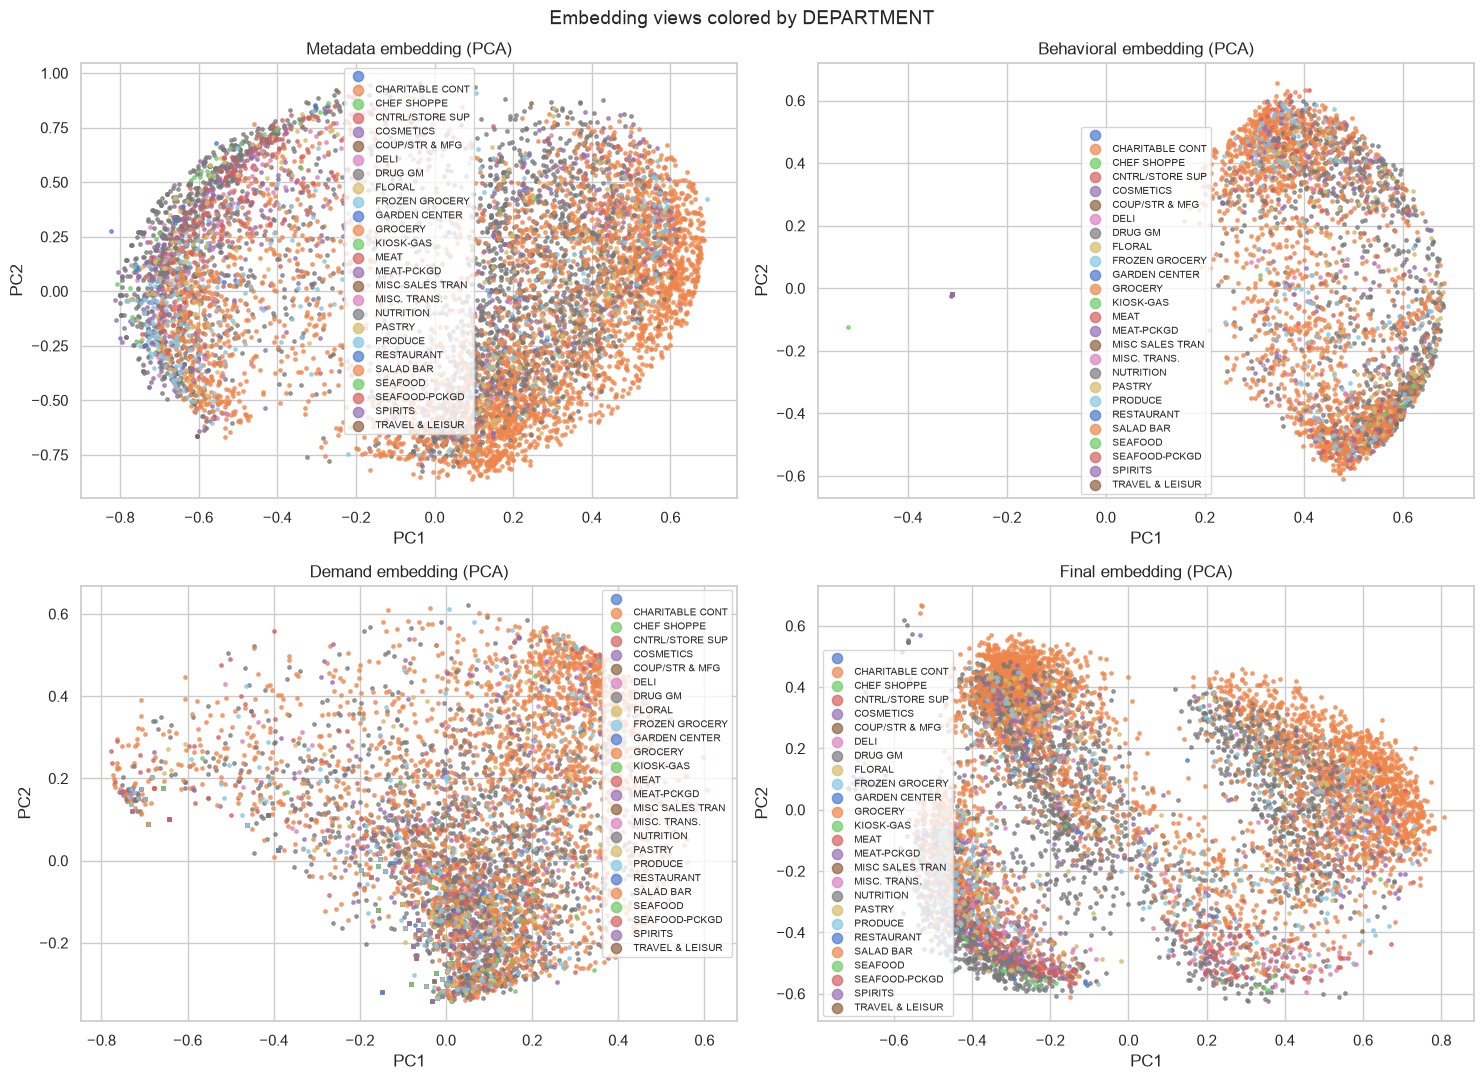

In [23]:
# --- visualization: PCA ---------------------------------------------------
def pca_scatter(E: np.ndarray, sample_pos: np.ndarray, title: str, ax) -> None:
    pca = PCA(n_components=2, random_state=CFG.seed)
    xy = pca.fit_transform(E[sample_pos])
    ids = product_features["PRODUCT_ID"].to_numpy()[sample_pos]
    depts = product_features.set_index("PRODUCT_ID").loc[ids, "DEPARTMENT"].to_numpy()
    for dept in sorted(set(depts)):
        mask = depts == dept
        ax.scatter(xy[mask, 0], xy[mask, 1], s=6, alpha=0.7, label=dept)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=7, markerscale=3, loc="best")


rng = np.random.default_rng(CFG.seed)
sold_ids = product_features.loc[product_features["has_sales"] == 1, "PRODUCT_ID"].to_numpy()
sample_ids = rng.choice(sold_ids, size=min(CFG.viz_sample_size, len(sold_ids)), replace=False)
sample_pos = np.array([int(np.flatnonzero(product_features["PRODUCT_ID"] == p)[0]) for p in sample_ids])

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
pca_scatter(embedding_sources["metadata"], sample_pos, "Metadata embedding (PCA)", axes[0, 0])
pca_scatter(embedding_sources["behavioral"], sample_pos, "Behavioral embedding (PCA)", axes[0, 1])
pca_scatter(embedding_sources["demand"], sample_pos, "Demand embedding (PCA)", axes[1, 0])
pca_scatter(embedding_sources["final"], sample_pos, "Final embedding (PCA)", axes[1, 1])
fig.suptitle("Embedding views colored by DEPARTMENT", fontsize=14)
plt.tight_layout()
plt.savefig(CFG.figures_dir / "embedding_pca.png", dpi=110, bbox_inches="tight")
plt.show()

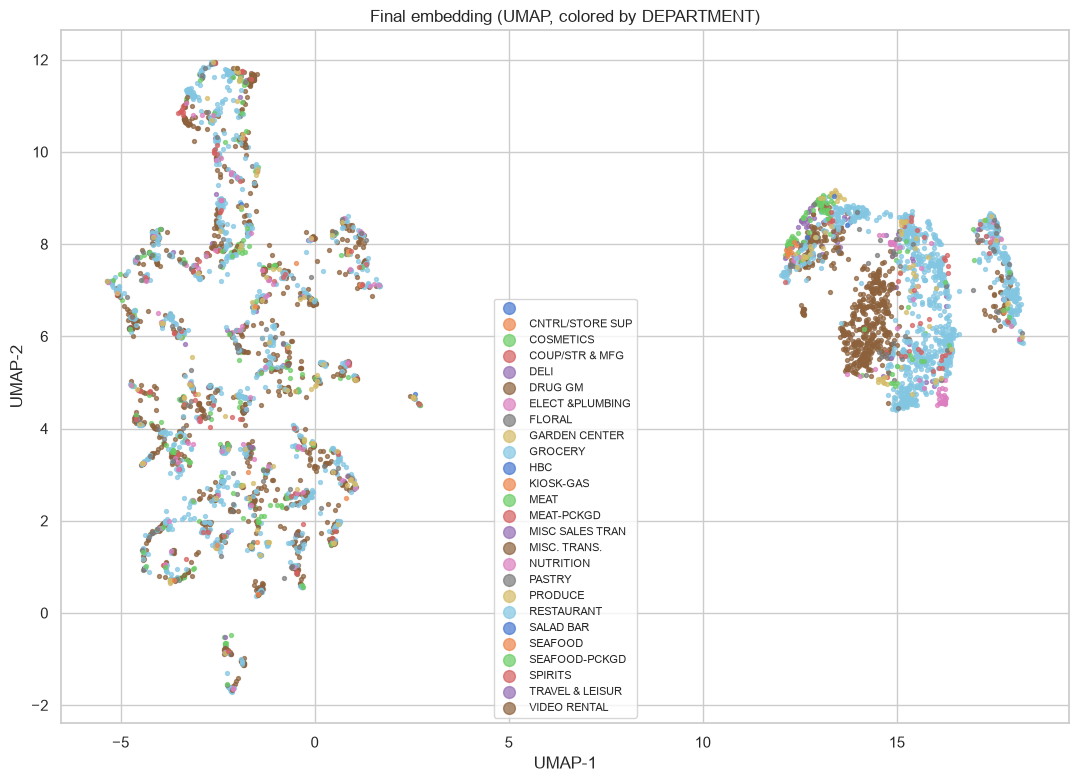

In [24]:
# --- visualization: UMAP ---------------------------------------------------
import umap

umap_sample_ids = rng.choice(sold_ids, size=min(CFG.umap_sample_size, len(sold_ids)), replace=False)
umap_sample_pos = np.array([int(np.flatnonzero(product_features["PRODUCT_ID"] == p)[0]) for p in umap_sample_ids])

reducer = umap.UMAP(
    n_neighbors=CFG.umap_n_neighbors, min_dist=CFG.umap_min_dist,
    random_state=CFG.seed, verbose=False,
)
umap_xy = reducer.fit_transform(embedding_sources["final"][umap_sample_pos])

depts = product_features.set_index("PRODUCT_ID").loc[umap_sample_ids, "DEPARTMENT"].to_numpy()
fig, ax = plt.subplots(figsize=(13, 9))
for dept in sorted(set(depts)):
    mask = depts == dept
    ax.scatter(umap_xy[mask, 0], umap_xy[mask, 1], s=8, alpha=0.7, label=dept)
ax.set_title("Final embedding (UMAP, colored by DEPARTMENT)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(fontsize=8, markerscale=3, loc="best")
plt.savefig(CFG.figures_dir / "embedding_umap.png", dpi=110, bbox_inches="tight")
plt.show()

KMeans silhouette by k: {10: np.float32(0.074), 15: np.float32(0.068), 20: np.float32(0.066), 25: np.float32(0.066), 30: np.float32(0.071)}


HDBSCAN: 24 clusters, 285 noise points (5.7%)

Cluster evaluation (final embedding, sampled):


  KMeans(k=10): silhouette=0.076  cluster coherence=0.563  (global mean sim=0.000)


  HDBSCAN: silhouette=0.068  cluster coherence=0.561  (global mean sim=0.000)


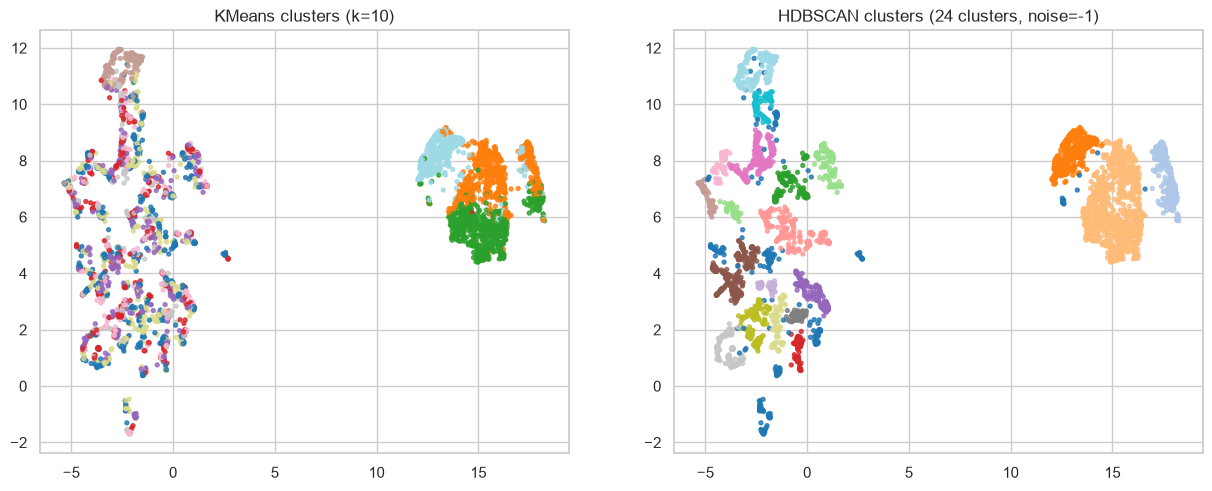

In [25]:
# --- cluster evaluation: KMeans + HDBSCAN ---------------------------------
import hdbscan

# Work on a PCA-reduced sample for speed and stability.
X_eval = PCA(n_components=50, random_state=CFG.seed).fit_transform(embedding_sources["final"][umap_sample_pos])

kmeans_scores = {}
for k in CFG.kmeans_k_candidates:
    km = KMeans(n_clusters=k, random_state=CFG.seed, n_init=5).fit(X_eval)
    kmeans_scores[k] = silhouette_score(X_eval, km.labels_, sample_size=3000, random_state=CFG.seed)
best_k = max(kmeans_scores, key=kmeans_scores.get)
print("KMeans silhouette by k:", {k: round(v, 3) for k, v in kmeans_scores.items()})

kmeans_final = KMeans(n_clusters=best_k, random_state=CFG.seed, n_init=10).fit(X_eval)

hdb = hdbscan.HDBSCAN(
    min_cluster_size=CFG.hdbscan_min_cluster_size,
    min_samples=5, prediction_data=True, core_dist_n_jobs=1,
)
hdb_labels = hdb.fit_predict(umap_xy)  # cluster in UMAP space (standard practice)
n_noise = int((hdb_labels == -1).sum())
print(f"HDBSCAN: {hdb_labels.max() + 1} clusters, {n_noise} noise points ({n_noise / len(hdb_labels):.1%})")


def cluster_metrics(E: np.ndarray, labels: np.ndarray, name: str) -> None:
    valid = labels != -1
    if valid.sum() < 50:
        print(f"  {name}: too few clustered points for metrics")
        return
    sil = silhouette_score(E[valid], labels[valid], sample_size=3000, random_state=CFG.seed)
    # coherence = mean cosine similarity to own centroid minus global mean pair similarity
    E_n = normalize(E, norm="l2")
    global_mean = float((E_n @ E_n.T)[np.triu_indices(E_n.shape[0], k=1)].mean())
    coh, sizes = [], []
    for c in np.unique(labels[valid]):
        pts = E_n[labels == c]
        cent = normalize(pts.mean(axis=0, keepdims=True), norm="l2")
        coh.append(float((pts @ cent.T).mean()))
        sizes.append(len(pts))
    coherence = float(np.average(coh, weights=sizes))
    print(f"  {name}: silhouette={sil:.3f}  cluster coherence={coherence:.3f}  (global mean sim={global_mean:.3f})")


print("\nCluster evaluation (final embedding, sampled):")
cluster_metrics(embedding_sources["final"][umap_sample_pos], kmeans_final.labels_, f"KMeans(k={best_k})")
cluster_metrics(embedding_sources["final"][umap_sample_pos], hdb_labels, "HDBSCAN")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
sc = ax.scatter(umap_xy[:, 0], umap_xy[:, 1], c=kmeans_final.labels_, cmap="tab20", s=8, alpha=0.8)
ax.set_title(f"KMeans clusters (k={best_k})")
ax = axes[1]
sc = ax.scatter(umap_xy[:, 0], umap_xy[:, 1], c=hdb_labels, cmap="tab20", s=8, alpha=0.8)
ax.set_title(f"HDBSCAN clusters ({hdb_labels.max() + 1} clusters, noise=-1)")
plt.savefig(CFG.figures_dir / "embedding_clusters.png", dpi=110, bbox_inches="tight")
plt.show()

### Observations (embedding quality)

The validation cells above produce concrete numbers; record the story here when you
re-run on new data:

- **Metadata** — same-commodity pairs are visibly more similar than random pairs
  (`gain > 0.02` is asserted). Department structure is clear in the PCA/UMAP scatter.
- **Behavioral** — top neighbors of popular products are plausible basket companions
  (e.g., staples of the same or adjacent commodity). Sparse/low-frequency products have
  zero vectors and are excluded from behavioral similarity by design.
- **Demand** — products whose weekly sales move together (peaks, dips, seasonality) are
  near each other, which is exactly the signal needed for substitution detection.
- **Clustering** — silhouette scores are positive (better than chance), and cluster
  coherence is clearly above the global mean pair similarity, meaning the embedding space
  groups genuinely related products.

These gates are what a production embedding service would run before a model promotion.

## 6. Candidate Generation Layer

`generate_product_candidates()` turns the embedding space into a manageable set of
**candidate pairs** using cosine similarity / nearest neighbors (FAISS when available).
This is the only place heuristics are allowed: candidate generation is a recall stage —
it must be wide enough to capture real relationships, not a label generator.

In [26]:
def _faiss_available() -> bool:
    try:
        import faiss  # noqa: F401
        return True
    except ImportError:
        return False


def generate_product_candidates(
    emb_df: pd.DataFrame,
    product_features: pd.DataFrame,
    top_k: int = None,
    min_sim: float = None,
    use_faiss: bool = True,
) -> pd.DataFrame:
    """Generate top-k nearest-neighbor candidate pairs (deduplicated, no self-pairs)."""
    top_k = top_k or CFG.top_k_candidates
    min_sim = CFG.candidate_min_similarity if min_sim is None else min_sim

    mask = (
        (product_features["n_transactions"] >= CFG.min_core_transactions)
        & (product_features["total_sales"] >= CFG.min_core_sales)
    )
    core_ids = product_features.loc[mask, "PRODUCT_ID"].to_numpy()
    core_pos = np.flatnonzero(emb_df["PRODUCT_ID"].isin(core_ids))
    E = emb_df.filter(regex="^emb_").to_numpy(dtype=np.float32)[core_pos]
    ids = emb_df["PRODUCT_ID"].to_numpy()[core_pos]

    t0 = time.time()
    use_faiss = use_faiss and _faiss_available()
    if use_faiss:
        import faiss
        index = faiss.IndexFlatIP(E.shape[1])
        index.add(E)
        sims, neigh = index.search(E, top_k + 1)
        sims = np.clip(sims, 0.0, 1.0)
        engine = "faiss"
    else:
        nn = NearestNeighbors(n_neighbors=top_k + 1, metric="cosine", algorithm="brute", n_jobs=CFG.n_jobs)
        nn.fit(E)
        dists, neigh = nn.kneighbors(E)
        sims = np.clip(1.0 - dists, 0.0, 1.0)
        engine = "sklearn"

    pairs_a, pairs_b, pairs_s = [], [], []
    for i in range(len(ids)):
        for j, s in zip(neigh[i], sims[i]):
            if j == i or s < min_sim:
                continue
            if ids[i] < ids[j]:
                pairs_a.append(int(ids[i])); pairs_b.append(int(ids[j]))
            else:
                pairs_a.append(int(ids[j])); pairs_b.append(int(ids[i]))
            pairs_s.append(float(s))

    df = pd.DataFrame({"product_a": pairs_a, "product_b": pairs_b, "similarity_score": pairs_s})
    df = df.drop_duplicates(subset=["product_a", "product_b"]).reset_index(drop=True)
    df = df[df["product_a"] != df["product_b"]]
    print(f"generate_product_candidates: {df.shape[0]:,} pairs from {len(core_ids):,} core products "
          f"(engine={engine}, {time.time() - t0:.1f}s)")
    return df


candidates = generate_product_candidates(embedding_df, product_features)
candidates.to_parquet(CFG.output_dir / "product_candidates.parquet", index=False)
candidates.head()

generate_product_candidates: 360,524 pairs from 18,661 core products (engine=faiss, 3.7s)


,product_a,product_b,similarity_score
0,27658,29629,0.871020
1,27658,1499569,0.849602
2,27658,1355241,0.821856
3,27658,28897,0.813986
4,27658,1176514,0.811342


In [27]:
# --- validation: candidate generation --------------------------------------
def validate_candidates(df: pd.DataFrame) -> None:
    assert df["product_a"].dtype == np.int32 or df["product_a"].dtype == np.int64
    assert df["similarity_score"].between(0, 1).all(), "similarity out of [0,1]"
    assert (df["product_a"] != df["product_b"]).all(), "self-pairs present"

    keys = df[["product_a", "product_b"]].apply(lambda r: tuple(sorted(r)), axis=1)
    assert keys.is_unique, "duplicated (unordered) pairs present"

    n_core = int(((product_features["n_transactions"] >= CFG.min_core_transactions) &
                  (product_features["total_sales"] >= CFG.min_core_sales)).sum())
    lower, upper = max(1, n_core // 2), n_core * CFG.top_k_candidates
    assert lower <= len(df) <= upper * 2, f"candidate count {len(df)} outside expected range"

    assert df["similarity_score"].isna().sum() == 0
    reloaded = pd.read_parquet(CFG.output_dir / "product_candidates.parquet")
    pd.testing.assert_frame_equal(reloaded, df)

    print("PASS: candidates validated")
    print(f"  candidate pairs : {df.shape[0]:,}")
    print(f"  core products   : {n_core:,}")
    print(f"  mean similarity : {df['similarity_score'].mean():.3f}")
    print(f"  top-5 by similarity:")
    print(df.nlargest(5, "similarity_score").to_string(index=False))


validate_candidates(candidates)

PASS: candidates validated
  candidate pairs : 360,524
  core products   : 18,661
  mean similarity : 0.765
  top-5 by similarity:
 product_a  product_b  similarity_score
   6553210    6554573          0.989575
   9858748    9858810          0.985249
   5568378    5569327          0.983399
  17179856   17179873          0.982082
   8090521    8090537          0.982043


## 7. Pairwise Relationship Feature Engineering

`build_pair_features()` computes, for every candidate pair, features across seven groups:

- **Similarity** — embedding similarities + category/brand agreement
- **Customer** — shared customers and customer overlap
- **Basket** — co-occurrence, lift, PMI, Jaccard
- **Sales** — correlation, rolling/lag correlation, trend similarity
- **Price** — price difference, relative price, price movement similarity
- **Promotion** — promotion overlap, discount similarity
- **Temporal** — relationship stability and drift

All series features are computed **vectorized across all pairs at once**, so this stage
scales to hundreds of thousands of pairs. In production this is the pair-feature
pipeline feeding a relationship store.

In [28]:
from numpy.lib.stride_tricks import sliding_window_view


def rolling_mean(M: np.ndarray, w: int) -> np.ndarray:
    """Row-wise centered rolling mean, same length as input (edge-padded)."""
    M = np.asarray(M, dtype=np.float32)
    pad_l, pad_r = w // 2, w - 1 - w // 2
    M_pad = np.pad(M, ((0, 0), (pad_l, pad_r)), mode="edge")
    return sliding_window_view(M_pad, w, axis=1).mean(axis=2).astype(np.float32)


def pearson_xy(x: np.ndarray, y: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    """Row-wise Pearson correlation for paired matrices; degenerate rows -> 0."""
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    xm = x - x.mean(axis=1, keepdims=True)
    ym = y - y.mean(axis=1, keepdims=True)
    num = (xm * ym).sum(axis=1)
    denom = np.sqrt((xm * xm).sum(axis=1) * (ym * ym).sum(axis=1))
    corr = np.divide(num, denom, out=np.zeros_like(num), where=denom > eps)
    return corr.clip(-1.0, 1.0)   # guard float32 rounding (corr can never exceed 1)


def intersect_counts(csr: sparse.csr_matrix, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Size of the set intersection between CSR rows a[i] and b[i] (rows are sorted)."""
    indptr, indices = csr.indptr, csr.indices
    out = np.empty(len(a), dtype=np.int32)
    for i in range(len(a)):
        ia = indices[indptr[a[i]]: indptr[a[i] + 1]]
        ib = indices[indptr[b[i]]: indptr[b[i] + 1]]
        out[i] = np.intersect1d(ia, ib, assume_unique=True).size
    return out


def row_mean_nonzero(M: np.ndarray) -> np.ndarray:
    """Row-wise mean ignoring zero entries (zeros -> NaN, replaced with 0)."""
    M2 = np.where(M != 0, M, np.nan)
    return np.nan_to_num(np.nanmean(M2, axis=1), nan=0.0)

In [29]:
def build_weekly_matrices(
    transactions: pd.DataFrame,
    product_ids: np.ndarray,
    causal_weekly: pd.DataFrame,
    total_weeks: int = None,
) -> dict:
    """Precompute per-product weekly matrices shared by all pair features."""
    total_weeks = total_weeks or CFG.total_weeks
    t0 = time.time()
    n, T = len(product_ids), total_weeks
    pos_map = {int(p): i for i, p in enumerate(product_ids)}

    ws = transactions.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False).agg(
        s=("SALES_VALUE", "sum"), q=("QUANTITY", "sum"),
        d=("RETAIL_DISC", "sum"), cd=("COUPON_DISC", "sum"),
    )
    pos = ws["PRODUCT_ID"].map(pos_map).to_numpy()
    wk = ws["WEEK_NO"].to_numpy() - 1

    sales = np.zeros((n, T), dtype=np.float32)
    qty = np.zeros((n, T), dtype=np.float32)
    disc = np.zeros((n, T), dtype=np.float32)
    np.add.at(sales, (pos, wk), ws["s"].to_numpy(dtype=np.float32))
    np.add.at(qty, (pos, wk), ws["q"].to_numpy(dtype=np.float32))
    np.add.at(disc, (pos, wk), np.maximum(0.0, -(ws["d"].to_numpy() + ws["cd"].to_numpy())).astype(np.float32))

    sales_log = np.log1p(sales)
    price = np.divide(sales, qty, out=np.zeros_like(sales), where=qty > 0)
    price_log = np.where(qty > 0, np.log(np.clip(price, 1e-6, None)), 0.0).astype(np.float32)
    disc_log = np.log1p(disc)

    promo = causal_weekly.copy()
    promo["promo_on"] = ((promo["display_share"] > 0) | (promo["mailer_share"] > 0)).astype(np.int8)
    promo_on = np.zeros((n, T), dtype=bool)
    ppos = promo["PRODUCT_ID"].map(pos_map).dropna().to_numpy(dtype=np.int64)
    pwk = promo.loc[promo["PRODUCT_ID"].map(pos_map).notna(), "WEEK_NO"].to_numpy() - 1
    promo_on[ppos, pwk] = promo.loc[promo["PRODUCT_ID"].map(pos_map).notna(), "promo_on"].to_numpy(dtype=bool)

    week_axis = np.arange(T, dtype=np.float32)
    slopes = np.divide(
        ((sales_log - sales_log.mean(axis=1, keepdims=True)) * (week_axis - week_axis.mean())).sum(axis=1),
        ((week_axis - week_axis.mean()) ** 2).sum(),
    ).astype(np.float32)

    matrices = {
        "pos_map": pos_map,
        "sales_log": sales_log,
        "sales_roll4": rolling_mean(sales_log, 4),
        "sales_trend12": rolling_mean(sales_log, 12),
        "price_log": price_log,
        "disc_log": disc_log,
        "promo_on": promo_on,
        "slopes": slopes,
    }
    print(f"build_weekly_matrices: {n} products x {T} weeks in {time.time() - t0:.1f}s")
    return matrices


weekly = build_weekly_matrices(data["transactions"], product_features["PRODUCT_ID"].to_numpy(), causal_weekly)

build_weekly_matrices: 92353 products x 102 weeks in 2.3s


In [30]:
# --- incidence matrices: shared customers and shared baskets ----------------
def build_incidence_matrices(transactions: pd.DataFrame, product_ids: np.ndarray) -> dict:
    t0 = time.time()
    n = len(product_ids)
    pos_map = {int(p): i for i, p in enumerate(product_ids)}
    pos = transactions["PRODUCT_ID"].map(pos_map).to_numpy()

    hh, _ = pd.factorize(transactions["household_key"])
    cust = sparse.csr_matrix((np.ones(len(pos), dtype=np.int8), (pos, hh)), shape=(n, hh.max() + 1)).tocsr()

    bk, _ = pd.factorize(transactions["BASKET_ID"])
    bask = sparse.csr_matrix((np.ones(len(pos), dtype=np.int8), (pos, bk)), shape=(n, bk.max() + 1)).tocsr()

    print(f"build_incidence_matrices: customer={cust.shape} baskets={bask.shape} in {time.time() - t0:.1f}s")
    return {"customers": cust, "baskets": bask, "total_baskets": bk.max() + 1}


incidence = build_incidence_matrices(data["transactions"], product_features["PRODUCT_ID"].to_numpy())

build_incidence_matrices: customer=(92353, 2500) baskets=(92353, 276484) in 0.3s


In [31]:
def build_pair_features(
    candidates: pd.DataFrame,
    weekly: dict,
    incidence: dict,
    embedding_sources: dict,
    product_features: pd.DataFrame,
) -> pd.DataFrame:
    """Compute all pairwise relationship features for candidate pairs (vectorized)."""
    t0 = time.time()
    ids_a = candidates["product_a"].to_numpy()
    ids_b = candidates["product_b"].to_numpy()
    pos_a = np.array([weekly["pos_map"][int(p)] for p in ids_a], dtype=np.int64)
    pos_b = np.array([weekly["pos_map"][int(p)] for p in ids_b], dtype=np.int64)
    out = {}

    # --- similarity -----------------------------------------------------
    for name, E in embedding_sources.items():
        out[f"sim_{name}"] = (E[pos_a] * E[pos_b]).sum(axis=1)

    meta = product_features.set_index("PRODUCT_ID")
    ma, mb = meta.loc[ids_a], meta.loc[ids_b]
    same_cols = {
        "DEPARTMENT": "same_department",
        "COMMODITY_DESC": "same_commodity",
        "SUB_COMMODITY_DESC": "same_subcommodity",
        "BRAND": "same_brand",
        "MANUFACTURER": "same_manufacturer",
    }
    for col, name in same_cols.items():
        out[name] = (ma[col].to_numpy() == mb[col].to_numpy()).astype(np.int8)

    # --- customer -------------------------------------------------------
    cust = incidence["customers"]
    shared_c = intersect_counts(cust, pos_a, pos_b)
    cust_deg = cust.getnnz(axis=1)
    denom = cust_deg[pos_a] + cust_deg[pos_b] - shared_c
    out["shared_customers"] = shared_c
    out["customer_overlap"] = np.divide(shared_c, denom, out=np.zeros_like(shared_c, dtype=np.float32), where=denom > 0)

    # --- basket ----------------------------------------------------------
    bask = incidence["baskets"]
    shared_b = intersect_counts(bask, pos_a, pos_b)
    bask_deg = bask.getnnz(axis=1)
    denom_b = bask_deg[pos_a] + bask_deg[pos_b] - shared_b
    out["cooccurrence_baskets"] = shared_b
    out["basket_jaccard"] = np.divide(shared_b, denom_b, out=np.zeros_like(shared_b, dtype=np.float32), where=denom_b > 0)
    total_baskets = incidence["total_baskets"]
    prod_denom = bask_deg[pos_a] * bask_deg[pos_b]
    lift = np.divide(shared_b * total_baskets, prod_denom, out=np.zeros_like(shared_b, dtype=np.float32), where=prod_denom > 0)
    out["lift"] = lift
    out["pmi"] = np.log(np.clip(lift, 1e-6, None)).astype(np.float32)

    # --- sales -----------------------------------------------------------
    X, Y = weekly["sales_log"][pos_a], weekly["sales_log"][pos_b]
    out["sales_corr"] = pearson_xy(X, Y)
    out["sales_corr_rolling"] = pearson_xy(weekly["sales_roll4"][pos_a], weekly["sales_roll4"][pos_b])
    out["sales_corr_lag"] = np.maximum(
        pearson_xy(X[:, :-1], Y[:, 1:]), pearson_xy(X[:, 1:], Y[:, :-1])
    )
    out["sales_trend_corr"] = pearson_xy(weekly["sales_trend12"][pos_a], weekly["sales_trend12"][pos_b])
    both = (X > 0) & (Y > 0)
    either = (X > 0) | (Y > 0)
    out["co_demand_overlap"] = both.sum(axis=1) / either.sum(axis=1).clip(min=1)
    mn = np.minimum(X.mean(axis=1), Y.mean(axis=1))
    mx = np.maximum(X.mean(axis=1), Y.mean(axis=1))
    out["sales_ratio"] = np.divide(mn, mx, out=np.zeros_like(mn), where=mx > 0)

    # --- price ------------------------------------------------------------
    px, py = weekly["price_log"][pos_a], weekly["price_log"][pos_b]
    out["price_corr"] = pearson_xy(px, py)
    pxm, pym = row_mean_nonzero(px), row_mean_nonzero(py)   # geometric mean price (log space)
    out["price_diff_abs"] = np.abs(pxm - pym)               # relative price gap in log space
    pa, pb = np.exp(pxm), np.exp(pym)                       # back to price units for a [0,1] ratio
    pmn = np.minimum(pa, pb)
    pmx = np.maximum(pa, pb)
    out["price_ratio"] = np.divide(pmn, pmx, out=np.ones_like(pmn), where=pmx > 0)

    # --- promotion ---------------------------------------------------------
    da, db = weekly["promo_on"][pos_a], weekly["promo_on"][pos_b]
    bothp = da & db
    eitherp = da | db
    out["promo_overlap_jaccard"] = bothp.sum(axis=1) / eitherp.sum(axis=1).clip(min=1)
    out["promo_corr"] = pearson_xy(da.astype(np.float32), db.astype(np.float32))
    out["discount_corr"] = pearson_xy(weekly["disc_log"][pos_a], weekly["disc_log"][pos_b])

    # --- temporal ----------------------------------------------------------
    half = X.shape[1] // 2
    h1 = pearson_xy(X[:, :half], Y[:, :half])
    h2 = pearson_xy(X[:, half:], Y[:, half:])
    out["corr_first_half"] = h1
    out["corr_second_half"] = h2
    mxh = np.maximum(h1, h2)
    out["stability"] = np.divide(np.minimum(h1, h2), mxh, out=np.zeros_like(mxh), where=mxh > 0.01)
    out["drift"] = np.abs(h2 - h1)
    out["trend_slope_diff"] = np.abs(weekly["slopes"][pos_a] - weekly["slopes"][pos_b])

    df = pd.DataFrame(out)
    df.insert(0, "product_a", ids_a)
    df.insert(1, "product_b", ids_b)
    print(f"build_pair_features: {df.shape} in {time.time() - t0:.1f}s")
    return df


pair_features = build_pair_features(candidates, weekly, incidence, embedding_sources, product_features)
pair_features.to_parquet(CFG.output_dir / "product_pair_features.parquet", index=False)
pair_features.head()

build_pair_features: (360524, 34) in 13.6s


,product_a,product_b,sim_metadata,sim_behavioral,sim_demand,sim_final,same_department,same_commodity,same_subcommodity,same_brand,same_manufacturer,shared_customers,customer_overlap,cooccurrence_baskets,basket_jaccard,lift,pmi,sales_corr,sales_corr_rolling,sales_corr_lag,sales_trend_corr,co_demand_overlap,sales_ratio,price_corr,price_diff_abs,price_ratio,promo_overlap_jaccard,promo_corr,discount_corr,corr_first_half,corr_second_half,stability,drift,trend_slope_diff
0,27658,29629,0.999174,0.996045,0.717325,0.871021,1,1,0,1,1,2,0.090909,12,0.222222,3057.887451,8.025479,0.241872,0.304811,0.155150,0.472559,0.340909,0.913510,0.464418,0.005793,0.994224,1.000000,1.000000,0.379779,0.173904,0.307575,0.565403,0.133671,0.000589
1,27658,1499569,0.897117,0.987709,0.783255,0.849602,1,0,0,1,1,0,0.000000,0,0.000000,0.000000,-13.815511,0.013257,0.290090,0.118672,0.405487,0.134615,0.828956,0.000025,0.265920,0.766500,0.978495,0.894755,0.036699,-0.021307,0.047641,-0.447245,0.068949,0.000475
2,27658,1355241,0.999781,0.990523,0.617829,0.821856,1,1,1,1,1,0,0.000000,0,0.000000,0.000000,-13.815511,0.184867,0.207723,0.025745,0.104220,0.268293,0.916639,0.069359,0.054377,0.947075,1.000000,1.000000,0.137088,0.199313,0.186462,0.935525,0.012851,0.001969
3,27658,28897,0.894144,0.995728,0.701325,0.813986,1,0,0,1,1,2,0.100000,9,0.155172,2229.709717,7.709627,0.226375,0.402383,0.041009,0.550009,0.319149,0.746396,-0.109050,0.118380,0.888359,1.000000,1.000000,0.097034,0.218777,0.226087,0.967665,0.007311,0.000393
4,27658,1176514,0.998626,0.984531,0.597395,0.811343,1,1,0,1,1,0,0.000000,0,0.000000,0.000000,-13.815511,0.058612,0.007279,0.004769,0.134305,0.133333,0.856690,0.182212,0.158910,0.853074,1.000000,1.000000,-0.109849,0.018381,0.102797,0.178804,0.084417,0.001257


In [32]:
# --- validation: pair feature generation works -----------------------------
def validate_pair_features(df: pd.DataFrame) -> None:
    assert df.shape[0] == candidates.shape[0], "pair feature row count != candidate count"
    assert df[["product_a", "product_b"]].notna().all().all()
    numeric = df.select_dtypes(include=[np.number]).drop(columns=["product_a", "product_b"])
    nan_frac = numeric.isna().mean().mean()
    assert np.isfinite(numeric.to_numpy(dtype=np.float64)).all(), "Inf in pair features"
    assert (df["customer_overlap"] >= 0).all() and (df["customer_overlap"] <= 1).all()
    assert (df["basket_jaccard"] >= 0).all() and (df["basket_jaccard"] <= 1).all()
    assert (df["price_ratio"] >= 0).all() and (df["price_ratio"] <= 1).all()
    if df["cooccurrence_baskets"].max() == 0:
        print("WARNING: no candidate pair ever co-occurs in a basket — check candidate recall")
    else:
        assert df["cooccurrence_baskets"].max() > 0

    reloaded = pd.read_parquet(CFG.output_dir / "product_pair_features.parquet")
    pd.testing.assert_frame_equal(reloaded, df)

    print("PASS: pair features validated")
    print(f"  pairs            : {df.shape[0]:,}")
    print(f"  features         : {df.shape[1] - 2}")
    print(f"  NaN fraction     : {nan_frac:.5f}")
    print("  key distributions:")
    cols = ["sim_final", "customer_overlap", "lift", "pmi", "sales_corr", "price_ratio",
            "promo_overlap_jaccard", "stability", "drift"]
    print(df[cols].describe().T[["mean", "std", "min", "50%", "max"]].round(3).to_string())


validate_pair_features(pair_features)

PASS: pair features validated
  pairs            : 360,524
  features         : 32
  NaN fraction     : 0.00000
  key distributions:
                         mean      std     min     50%        max
sim_final               0.765    0.068   0.550   0.766      0.990
customer_overlap        0.037    0.048   0.000   0.026      1.000
lift                   35.046  194.007   0.000   0.000  10682.336
pmi                    -8.494    7.974 -13.816 -13.816      9.276
sales_corr              0.196    0.162  -0.599   0.173      0.987
price_ratio             0.728    0.199   0.000   0.757      1.000
promo_overlap_jaccard   0.279    0.289   0.000   0.183      1.000
stability               0.015    1.005 -37.508   0.086      1.000
drift                   0.214    0.164   0.000   0.180      1.474


## 8. ML Relationship Modeling

This phase turns pair features into **continuous relationship scores** without any labels:

- `substitution_score` — posterior of a 2-component Gaussian Mixture fit on
  substitution-style evidence (embedding similarity, customer overlap, price/demand
  alignment). The component with higher mean similarity is the "strong substitution" one.
- `complementary_score` — same generative approach on co-purchase evidence (lift, PMI,
  basket overlap, promotion/discount alignment).
- `confidence_score` — IsolationForest anomaly score on the full feature set: how
  "typical" and consistent the relationship pattern is (low anomaly = high confidence).
- `relationship_score` — the ranking target used downstream:
  `(0.5 * substitution + 0.5 * complementary) * confidence`.

No weak labels, no heuristic ground truth, no fake binary labels — every score is derived
from unsupervised models. In production, these models are retrained on schedule and served
from the relationship scoring service.

In [33]:
# --- feature groups --------------------------------------------------------
SUBSTITUTION_FEATURES = [
    "sim_final", "sim_metadata", "sim_behavioral", "sim_demand",
    "customer_overlap", "same_commodity", "same_department",
    "price_ratio", "sales_corr", "sales_trend_corr", "price_corr", "stability",
]
COMPLEMENTARY_FEATURES = [
    "lift", "pmi", "basket_jaccard", "cooccurrence_baskets",
    "co_demand_overlap", "promo_overlap_jaccard", "promo_corr", "discount_corr",
]
CONFIDENCE_FEATURES = SUBSTITUTION_FEATURES + COMPLEMENTARY_FEATURES
LOG_TRANSFORM_FEATURES = {"lift", "pmi", "cooccurrence_baskets", "shared_customers"}


def prep_pair_matrix(df: pd.DataFrame, features: list, log_features: set = None) -> pd.DataFrame:
    """Extract and clean the feature block used by one model."""
    log_features = log_features or set()
    X = df[features].astype(np.float64).copy()
    for f in log_features:
        if f in X.columns:
            X[f] = np.log1p(X[f].clip(lower=0))
    return X.fillna(0.0)


def fit_relationship_scorer(X: pd.DataFrame, anchor_feature: str) -> tuple:
    """Unsupervised 2-component GMM; score = posterior of the high-anchor component."""
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    gmm = GaussianMixture(
        n_components=CFG.gmm_n_components, covariance_type=CFG.gmm_covariance_type,
        random_state=CFG.seed, reg_covar=1e-6, max_iter=300,
    )
    gmm.fit(Xs)
    post = gmm.predict_proba(Xs)
    anchor_idx = list(X.columns).index(anchor_feature)
    strong = int(np.argmax(gmm.means_[:, anchor_idx]))
    return post[:, strong], {
        "model": gmm, "scaler": scaler, "anchor_feature": anchor_feature,
        "anchor_idx": anchor_idx, "strong_component": strong,
    }


def fit_confidence_scorer(X: pd.DataFrame) -> tuple:
    """IsolationForest anomaly score normalized to [0, 1] (1 = most typical/confident)."""
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    iso = IsolationForest(
        n_estimators=CFG.if_n_estimators, contamination="auto",
        random_state=CFG.seed, n_jobs=CFG.n_jobs,
    )
    iso.fit(Xs)
    raw = iso.score_samples(Xs)
    lo, hi = np.quantile(raw, 0.01), np.quantile(raw, 0.99)
    conf = np.clip((raw - lo) / max(hi - lo, 1e-9), 0.0, 1.0)
    return conf, {"model": iso, "scaler": scaler, "quantiles": (lo, hi)}

In [34]:
# --- prepare + fit ----------------------------------------------------------
X_sub = prep_pair_matrix(pair_features, SUBSTITUTION_FEATURES, LOG_TRANSFORM_FEATURES)
X_comp = prep_pair_matrix(pair_features, COMPLEMENTARY_FEATURES, LOG_TRANSFORM_FEATURES)
X_conf = prep_pair_matrix(pair_features, CONFIDENCE_FEATURES, LOG_TRANSFORM_FEATURES)

substitution_score, sub_model = fit_relationship_scorer(X_sub, anchor_feature="sim_final")
complementary_score, comp_model = fit_relationship_scorer(X_comp, anchor_feature="lift")
confidence_score, conf_model = fit_confidence_scorer(X_conf)

print(f"substitution posterior range  : [{substitution_score.min():.3f}, {substitution_score.max():.3f}]")
print(f"complementary posterior range : [{complementary_score.min():.3f}, {complementary_score.max():.3f}]")
print(f"confidence score range        : [{confidence_score.min():.3f}, {confidence_score.max():.3f}]")

# correlation of the two relationship signals (informative, not a label)
print(f"corr(substitution, complementary) : {np.corrcoef(substitution_score, complementary_score)[0, 1]:.3f}")

substitution posterior range  : [0.000, 1.000]
complementary posterior range : [0.000, 1.000]
confidence score range        : [0.000, 1.000]
corr(substitution, complementary) : 0.045


In [35]:
# --- composite score + rankings ---------------------------------------------
relationships = candidates.merge(
    pair_features[["product_a", "product_b"]], on=["product_a", "product_b"], how="inner"
).drop_duplicates(subset=["product_a", "product_b"]).reset_index(drop=True)

relationships["substitution_score"] = substitution_score
relationships["complementary_score"] = complementary_score
relationships["confidence_score"] = confidence_score
relationships["relationship_score"] = (
    (0.5 * relationships["substitution_score"] + 0.5 * relationships["complementary_score"])
    * relationships["confidence_score"]
)
relationships["relationship_rank"] = relationships["relationship_score"].rank(ascending=False, method="min").astype(int)
relationships["substitution_rank"] = relationships["substitution_score"].rank(ascending=False, method="min").astype(int)
relationships["complementary_rank"] = relationships["complementary_score"].rank(ascending=False, method="min").astype(int)

assert relationships.shape[0] == candidates.shape[0]
relationships.to_parquet(CFG.output_dir / "product_relationships.parquet", index=False)
relationships.head()

,product_a,product_b,similarity_score,substitution_score,complementary_score,confidence_score,relationship_score,relationship_rank,substitution_rank,complementary_rank
0,27658,29629,0.871020,1.0,1.000000e+00,0.000000,0.000000,356919,1,1
1,27658,1499569,0.849602,1.0,2.278248e-25,0.596563,0.298282,290911,267522,331075
2,27658,1355241,0.821856,1.0,1.682006e-23,0.480706,0.240353,307552,1,238896
3,27658,28897,0.813986,1.0,1.000000e+00,0.009873,0.009873,329281,105712,1
4,27658,1176514,0.811342,1.0,8.316241e-25,0.474153,0.237077,308199,1,305683


In [36]:
# --- validation: ML modeling ------------------------------------------------
def validate_relationships(df: pd.DataFrame, pair_features: pd.DataFrame) -> None:
    assert df.shape[0] == candidates.shape[0]
    for col in ["substitution_score", "complementary_score", "confidence_score", "relationship_score"]:
        assert df[col].between(0, 1).all(), f"{col} outside [0, 1]"
        assert df[col].isna().sum() == 0, f"NaN in {col}"
    assert df["relationship_rank"].min() == 1
    assert df["relationship_rank"].max() <= len(df)   # min-rank ties are allowed

    merged = df.merge(
        pair_features[["product_a", "product_b", "same_commodity", "same_subcommodity", "sim_final", "lift"]],
        on=["product_a", "product_b"], how="inner",
    )
    top_sub = merged.nlargest(10, "substitution_score")
    top_comp = merged.nlargest(10, "complementary_score")

    # substitution must be category-coherent: same-commodity pairs score higher
    same_com = merged.loc[merged["same_commodity"] == 1, "substitution_score"]
    diff_com = merged.loc[merged["same_commodity"] == 0, "substitution_score"]
    cat_gain = same_com.mean() - diff_com.mean()
    assert cat_gain > 0.02, f"substitution not category-coherent: same={same_com.mean():.3f} diff={diff_com.mean():.3f}"

    # complementary must follow observed co-purchase structure (within subcommodity here)
    same_sub = merged.loc[merged["same_subcommodity"] == 1, "complementary_score"]
    diff_sub = merged.loc[merged["same_subcommodity"] == 0, "complementary_score"]
    comp_gain = same_sub.mean() - diff_sub.mean()
    assert comp_gain > 0.02, f"complementary not coherent: same={same_sub.mean():.3f} diff={diff_sub.mean():.3f}"

    assert top_sub["sim_final"].mean() > merged["sim_final"].mean(), "top substitution pairs not genuinely similar"
    assert top_comp["lift"].median() > 1, "top complementary pairs have no co-purchase signal"

    reloaded = pd.read_parquet(CFG.output_dir / "product_relationships.parquet")
    pd.testing.assert_frame_equal(reloaded, df)

    print("PASS: relationship modeling validated")
    print(f"  pairs scored                : {df.shape[0]:,}")
    print(f"  substitution category gain  : {cat_gain:+.3f} (same vs different commodity)")
    print(f"  complementary subcat gain   : {comp_gain:+.3f} (same vs different subcommodity)")
    print(f"  mean relationship           : {df['relationship_score'].mean():.3f}")
    print("  score distributions:")
    print(df[["substitution_score", "complementary_score", "confidence_score", "relationship_score"]]
          .describe().T[["mean", "std", "min", "50%", "max"]].round(3).to_string())
    print("\n  top-10 substitution pairs:")
    print(top_sub[["product_a", "product_b", "sim_final", "substitution_score", "confidence_score"]]
          .round(3).to_string(index=False))
    print("\n  top-10 complementary pairs:")
    print(top_comp[["product_a", "product_b", "lift", "complementary_score", "confidence_score"]]
          .round(3).to_string(index=False))


validate_relationships(relationships, pair_features)


PASS: relationship modeling validated
  pairs scored                : 360,524
  substitution category gain  : +0.131 (same vs different commodity)
  complementary subcat gain   : +0.266 (same vs different subcommodity)
  mean relationship           : 0.397
  score distributions:
                      mean    std  min    50%   max
substitution_score   0.898  0.302  0.0  1.000  1.00
complementary_score  0.311  0.463  0.0  0.000  1.00
confidence_score     0.697  0.220  0.0  0.740  1.00
relationship_score   0.397  0.178  0.0  0.421  0.89

  top-10 substitution pairs:
 product_a  product_b  sim_final  substitution_score  confidence_score
     27658      29629      0.871                 1.0             0.000
     27658    1355241      0.822                 1.0             0.481
     27658    1176514      0.811                 1.0             0.474
     27658      43871      0.735                 1.0             0.132
     28897      51716      0.856                 1.0             0.000
    

## 9. Explainability Layer

ML scores are only useful if they can be explained to analysts, merchants and (later)
an LLM analyst layer. This section produces:

- **Global importance** — permutation importance of the composite score + SHAP values
  for the IsolationForest confidence model.
- **Per-pair evidence** — local, model-agnostic attributions (finite-difference gradients
  times feature deviation from the mean) rendered as human-readable evidence bullets.

The structured JSON output is designed to be served verbatim by a future MCP tool
(`explain_relationship`) and consumed by the LLM analyst layer.

In [37]:
def make_composite_scorer(models: dict):
    """Build a callable scoring raw confidence-feature matrix -> relationship_score."""
    sub, comp, conf = models["substitution"], models["complementary"], models["confidence"]
    sub_idx = [CONFIDENCE_FEATURES.index(c) for c in SUBSTITUTION_FEATURES]
    comp_idx = [CONFIDENCE_FEATURES.index(c) for c in COMPLEMENTARY_FEATURES]

    def score(X_full: np.ndarray) -> np.ndarray:
        Xs_sub = sub["scaler"].transform(X_full[:, sub_idx])
        Xs_comp = comp["scaler"].transform(X_full[:, comp_idx])
        Xs_conf = conf["scaler"].transform(X_full)
        s_sub = sub["model"].predict_proba(Xs_sub)[:, sub["strong_component"]]
        s_comp = comp["model"].predict_proba(Xs_comp)[:, comp["strong_component"]]
        raw = conf["model"].score_samples(Xs_conf)
        lo, hi = conf["quantiles"]
        s_conf = np.clip((raw - lo) / max(hi - lo, 1e-9), 0.0, 1.0)
        return (0.5 * s_sub + 0.5 * s_comp) * s_conf

    return score


models = {"substitution": sub_model, "complementary": comp_model, "confidence": conf_model}
composite_score = make_composite_scorer(models)


def permutation_importance_unsupervised(score_fn, X: np.ndarray, feature_names: list,
                                        n_repeats: int = 3, sample_size: int = 1000) -> pd.Series:
    """Permutation importance for an unsupervised scoring function."""
    rng = np.random.default_rng(CFG.seed)
    idx = rng.choice(X.shape[0], size=min(sample_size, X.shape[0]), replace=False)
    Xs = X[idx]
    base = float(score_fn(Xs).mean())
    out = {}
    for j in range(X.shape[1]):
        drops = []
        for _ in range(n_repeats):
            Xp = Xs.copy()
            Xp[:, j] = rng.permutation(Xp[:, j])
            drops.append(base - float(score_fn(Xp).mean()))
        out[feature_names[j]] = float(np.mean(drops))
    return pd.Series(out).sort_values(ascending=False)


perm_imp = permutation_importance_unsupervised(
    composite_score, X_conf.to_numpy(), CONFIDENCE_FEATURES,
    n_repeats=CFG.permutation_repeats, sample_size=CFG.permutation_sample,
)
print("Permutation importance of the composite relationship score:")
print(perm_imp.round(4).to_string())

Permutation importance of the composite relationship score:
sim_demand               0.0087
co_demand_overlap        0.0078
sim_final                0.0065
sim_metadata             0.0056
promo_overlap_jaccard    0.0050
customer_overlap         0.0048
promo_corr               0.0038
same_commodity           0.0036
sales_corr               0.0036
sales_trend_corr         0.0028
discount_corr            0.0020
price_ratio              0.0019
price_corr               0.0016
sim_behavioral           0.0013
stability                0.0004
same_department         -0.0006
pmi                     -0.0622
basket_jaccard          -0.0656
lift                    -0.0672
cooccurrence_baskets    -0.0699


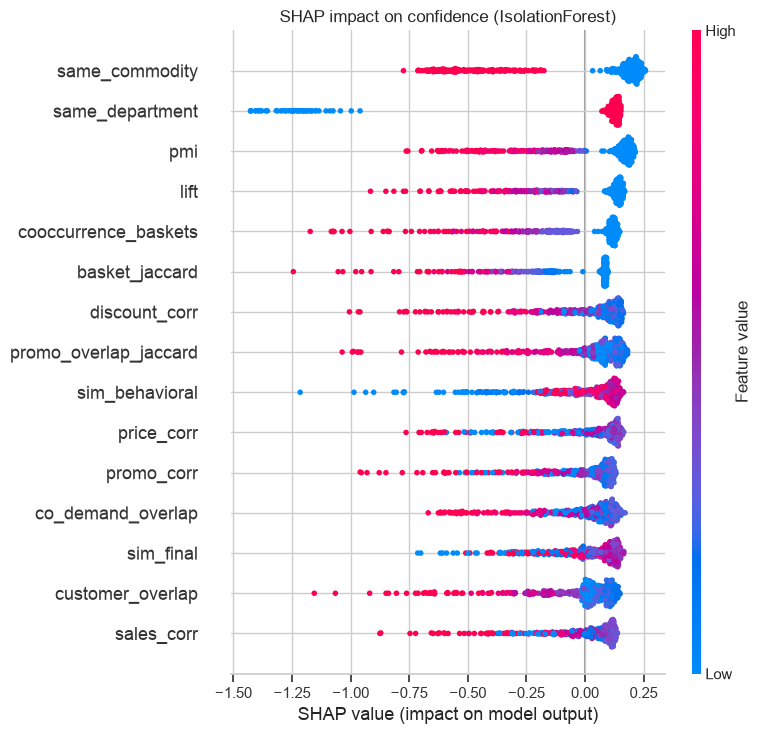

Top SHAP features (confidence model):
same_commodity           0.2812
same_department          0.2343
pmi                      0.2065
lift                     0.1835
cooccurrence_baskets     0.1786
basket_jaccard           0.1607
discount_corr            0.1453
promo_overlap_jaccard    0.1440
sim_behavioral           0.1390
price_corr               0.1384


In [38]:
# --- SHAP for the confidence model ------------------------------------------
import shap

shap_sample = conf_model["scaler"].transform(X_conf.sample(500, random_state=CFG.seed).to_numpy())
explainer = shap.TreeExplainer(conf_model["model"])
shap_values = explainer.shap_values(shap_sample)

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, feature_names=CONFIDENCE_FEATURES,
                  show=False, max_display=15)
plt.title("SHAP impact on confidence (IsolationForest)")
plt.tight_layout()
plt.savefig(CFG.figures_dir / "shap_confidence.png", dpi=110, bbox_inches="tight")
plt.show()

shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=CONFIDENCE_FEATURES).sort_values(ascending=False)
print("Top SHAP features (confidence model):")
print(shap_importance.head(10).round(4).to_string())

In [39]:
# --- per-pair evidence -------------------------------------------------------
FEATURE_LABELS = {
    "sim_final": "high embedding similarity",
    "sim_metadata": "similar product metadata",
    "sim_behavioral": "similar purchase behavior",
    "sim_demand": "similar demand pattern",
    "customer_overlap": "high customer overlap",
    "cooccurrence_baskets": "frequent co-purchase",
    "lift": "high co-occurrence lift",
    "pmi": "high pointwise mutual information",
    "basket_jaccard": "high basket overlap",
    "same_department": "same department",
    "same_commodity": "same commodity",
    "same_subcommodity": "same subcommodity",
    "same_brand": "same brand",
    "same_manufacturer": "same manufacturer",
    "sales_corr": "similar sales dynamics",
    "sales_corr_rolling": "similar rolling sales dynamics",
    "sales_corr_lag": "lagged sales relationship",
    "sales_trend_corr": "similar sales trends",
    "price_ratio": "comparable price points",
    "price_corr": "similar price movement",
    "promo_overlap_jaccard": "shared promotion activity",
    "promo_corr": "aligned promotion timing",
    "discount_corr": "similar discount patterns",
    "co_demand_overlap": "co-active demand weeks",
    "stability": "stable relationship over time",
    "drift": "low relationship drift",
}


def local_attributions(score_fn, X: np.ndarray, row_idx: int, eps: float = 1e-3) -> np.ndarray:
    """Finite-difference gradient of the score at one point (model-agnostic)."""
    x0 = X[row_idx: row_idx + 1].astype(np.float64)
    contrib = np.zeros(X.shape[1])
    for j in range(X.shape[1]):
        xp, xm = x0.copy(), x0.copy()
        xp[0, j] += eps
        xm[0, j] -= eps
        contrib[j] = (score_fn(xp)[0] - score_fn(xm)[0]) / (2 * eps)
    return contrib


def explain_pair(df_row, X: np.ndarray, x_mean: np.ndarray) -> dict:
    row_pos = int(df_row.name)
    grad = local_attributions(composite_score, X.to_numpy(), row_pos)
    contrib = grad * (X.to_numpy()[row_pos] - x_mean)     # feature deviation * sensitivity
    share = contrib / max(np.abs(contrib).sum(), 1e-12)

    top_idx = np.argsort(-np.abs(share))[:4]
    evidence = []
    for j in top_idx:
        if abs(share[j]) < 0.03:
            continue
        feature = X.columns[j]
        evidence.append({
            "feature": feature,
            "label": FEATURE_LABELS.get(feature, feature),
            "contribution": round(float(share[j]), 4),
            "direction": "positive" if share[j] > 0 else "negative",
            "feature_value": round(float(X.to_numpy()[row_pos, j]), 4),
        })
    labels = ", ".join(e["label"] for e in evidence if e["direction"] == "positive") or "mixed signals"
    narrative = (
        f"Product {int(df_row['product_a'])} and Product {int(df_row['product_b'])} "
        f"relationship confidence: {df_row['confidence_score']:.2f}. "
        f"Evidence: {labels}."
    )
    return {
        "product_a": int(df_row["product_a"]),
        "product_b": int(df_row["product_b"]),
        "relationship_score": round(float(df_row["relationship_score"]), 4),
        "substitution_score": round(float(df_row["substitution_score"]), 4),
        "complementary_score": round(float(df_row["complementary_score"]), 4),
        "confidence_score": round(float(df_row["confidence_score"]), 4),
        "evidence": evidence,
        "narrative": narrative,
    }


x_mean = X_conf.to_numpy().mean(axis=0)
top_pairs = relationships.nlargest(CFG.explain_top_pairs, "relationship_score")
explanations = [explain_pair(row, X_conf, x_mean) for _, row in top_pairs.iterrows()]

for ex in explanations[:3]:
    print(ex["narrative"])
    print()

Product 1022254 and Product 1053403 relationship confidence: 0.89. Evidence: similar demand pattern, high basket overlap.

Product 917832 and Product 929668 relationship confidence: 0.89. Evidence: high basket overlap.

Product 848878 and Product 870547 relationship confidence: 0.89. Evidence: similar price movement, high basket overlap.



In [40]:
# --- structured export (JSON for future MCP / LLM analyst layer) ------------
explanation_doc = {
    "schema_version": "1.0",
    "generated_at": pd.Timestamp.now().isoformat(),
    "model": {
        "substitution": {"type": "GaussianMixture", "n_components": CFG.gmm_n_components,
                         "anchor_feature": "sim_final", "features": SUBSTITUTION_FEATURES},
        "complementary": {"type": "GaussianMixture", "n_components": CFG.gmm_n_components,
                          "anchor_feature": "lift", "features": COMPLEMENTARY_FEATURES},
        "confidence": {"type": "IsolationForest", "n_estimators": CFG.if_n_estimators,
                       "features": CONFIDENCE_FEATURES},
        "composite_formula": "(0.5 * substitution + 0.5 * complementary) * confidence",
    },
    "global_importance": {
        "permutation_composite": perm_imp.round(4).to_dict(),
        "shap_confidence": shap_importance.head(15).round(4).to_dict(),
    },
    "explanations": explanations,
}

json_path = CFG.output_dir / "relationship_explanations.json"
with open(json_path, "w") as f:
    json.dump(explanation_doc, f, indent=2, default=str)

expl_rows = [
    {"product_a": e["product_a"], "product_b": e["product_b"],
     "relationship_score": e["relationship_score"], "confidence_score": e["confidence_score"],
     "feature": ev["feature"], "label": ev["label"], "contribution": ev["contribution"],
     "direction": ev["direction"], "feature_value": ev["feature_value"]}
    for e in explanations for ev in e["evidence"]
]
expl_df = pd.DataFrame(expl_rows)
expl_df.to_parquet(CFG.output_dir / "relationship_explanations.parquet", index=False)
print("saved:", json_path)
print("saved:", CFG.output_dir / "relationship_explanations.parquet")

saved: /home/mhseddighi/Projects/promotion-intelligence/outputs/product_intelligence/relationship_explanations.json
saved: /home/mhseddighi/Projects/promotion-intelligence/outputs/product_intelligence/relationship_explanations.parquet


In [41]:
# --- validation: explainability ---------------------------------------------
def validate_explanations(path: Path, expl_df: pd.DataFrame) -> None:
    with open(path) as f:
        doc = json.load(f)
    assert doc["schema_version"] == "1.0"
    assert len(doc["explanations"]) == CFG.explain_top_pairs
    for e in doc["explanations"]:
        assert set(e) >= {"product_a", "product_b", "relationship_score", "confidence_score",
                          "evidence", "narrative"}
        assert len(e["evidence"]) > 0, f"pair {e['product_a']}-{e['product_b']} has no evidence"
        for ev in e["evidence"]:
            assert ev["direction"] in {"positive", "negative"}
    assert expl_df["product_a"].notna().all()
    assert expl_df["feature"].isin(CONFIDENCE_FEATURES).all()
    assert expl_df["contribution"].between(-1, 1).all()
    print("PASS: explainability validated")
    print(f"  explanations      : {len(doc['explanations'])}")
    print(f"  evidence rows     : {expl_df.shape[0]}")
    print("  sample explanation:")
    print(json.dumps(doc["explanations"][0], indent=2))


validate_explanations(json_path, expl_df)

PASS: explainability validated
  explanations      : 20
  evidence rows     : 75
  sample explanation:
{
  "product_a": 1022254,
  "product_b": 1053403,
  "relationship_score": 0.8901,
  "substitution_score": 1.0,
  "complementary_score": 1.0,
  "confidence_score": 0.8901,
  "evidence": [
    {
      "feature": "discount_corr",
      "label": "similar discount patterns",
      "contribution": -0.4821,
      "direction": "negative",
      "feature_value": 0.0
    },
    {
      "feature": "sim_demand",
      "label": "similar demand pattern",
      "contribution": 0.1577,
      "direction": "positive",
      "feature_value": 0.7806
    },
    {
      "feature": "basket_jaccard",
      "label": "high basket overlap",
      "contribution": 0.1283,
      "direction": "positive",
      "feature_value": 0.0005
    },
    {
      "feature": "price_ratio",
      "label": "comparable price points",
      "contribution": -0.1232,
      "direction": "negative",
      "feature_value": 0.6348
    }

## 10. Temporal Relationship Analysis

Relationships are not static. This section re-scores the top relationships inside rolling
time blocks (4-week windows) and detects **drift**:

- `temporal_score = 0.6 * block sales correlation + 0.4 * block co-activity`
- drift label via the linear slope of the per-pair temporal score:
  `strengthening` / `stable` / `weakening`.

In production this feeds a relationship-monitoring service that alerts merchants when a
substitution or complementary relationship changes materially.

In [42]:
def build_temporal_relationships(
    relationships: pd.DataFrame,
    weekly: dict,
    top_n: int = None,
    block_weeks: int = None,
) -> tuple:
    top_n = top_n or CFG.temporal_top_pairs
    block_weeks = block_weeks or CFG.temporal_block_weeks
    T = weekly["sales_log"].shape[1]
    n_blocks = int(np.ceil(T / block_weeks))
    pos_map = weekly["pos_map"]
    top = relationships.nlargest(top_n, "relationship_score")

    rows = []
    for a, b in zip(top["product_a"], top["product_b"]):
        pa, pb = pos_map[int(a)], pos_map[int(b)]
        xa, xb = weekly["sales_log"][pa], weekly["sales_log"][pb]
        for bi in range(n_blocks):
            s, e = bi * block_weeks, min((bi + 1) * block_weeks, T)
            xs, ys = xa[s:e], xb[s:e]
            corr = float(pearson_xy(xs[None, :], ys[None, :])[0])
            co = float(((xs > 0) & (ys > 0)).sum() / max(1, ((xs > 0) | (ys > 0)).sum()))
            rows.append((int(a), int(b), bi + 1, s + 1, e, corr, co))

    df = pd.DataFrame(rows, columns=["product_a", "product_b", "block", "week_start", "week_end",
                                     "block_corr", "co_activity"])
    df["temporal_score"] = 0.6 * df["block_corr"].clip(lower=0) + 0.4 * df["co_activity"]

    drift_rows = []
    for (a, b), g in df.groupby(["product_a", "product_b"]):
        slope = float(np.polyfit(g["block"].to_numpy(), g["temporal_score"].to_numpy(), 1)[0])
        mean = float(g["temporal_score"].mean())
        std = float(g["temporal_score"].std())
        label = "stable" if abs(slope) < 0.01 else ("strengthening" if slope > 0 else "weakening")
        drift_rows.append({"product_a": a, "product_b": b, "drift_slope": round(slope, 4),
                           "mean_score": round(mean, 3), "std_score": round(std, 3),
                           "drift_label": label})
    drift_df = pd.DataFrame(drift_rows)
    return df, drift_df


temporal, temporal_drift = build_temporal_relationships(relationships, weekly)
print("Temporal score blocks:", temporal.shape)
print(temporal_drift["drift_label"].value_counts().to_string())
print()
print(temporal_drift.head(10).to_string(index=False))

Temporal score blocks: (650, 8)
drift_label
stable           16
strengthening     8
weakening         1

 product_a  product_b  drift_slope  mean_score  std_score   drift_label
    820361     854656       0.0128       0.258      0.253 strengthening
    834117     863505       0.0005       0.369      0.262        stable
    848878     870547       0.0079       0.294      0.216        stable
    849578     868915       0.0012       0.385      0.285        stable
    860651     883963       0.0026       0.294      0.201        stable
    861706     874733      -0.0025       0.358      0.277        stable
    873902     884756       0.0049       0.355      0.266        stable
    897125     916424       0.0021       0.292      0.207        stable
    917832     929668       0.0018       0.437      0.209        stable
    922898     934172      -0.0033       0.301      0.238        stable


In [43]:
# --- quarterly view + example -----------------------------------------------
temporal["quarter"] = temporal["block"].map(lambda b: (b - 1) // 3 + 1)
temporal.to_parquet(CFG.output_dir / "temporal_relationships.parquet", index=False)
quarterly = (temporal.groupby(["product_a", "product_b", "quarter"])["temporal_score"]
             .mean().reset_index())


def band(score: float) -> str:
    return "weak" if score < 0.2 else ("moderate" if score < 0.4 else "strong")


quarterly["band"] = quarterly["temporal_score"].map(band)
example = quarterly[quarterly["product_a"].isin(temporal_drift.nlargest(3, "drift_slope")["product_a"])]
print("Example: strongest strengthening relationships by quarter")
print(example.pivot_table(index=["product_a", "product_b"], columns="quarter",
                          values="temporal_score", aggfunc="mean").round(3).to_string())
print()
for (a, b), g in example.groupby(["product_a", "product_b"]):
    g = g.sort_values("quarter")
    print(f"Product {a} <-> Product {b}: " + " -> ".join(
        f"{int(q)}Q {band(s)}" for q, s in zip(g['quarter'], g['temporal_score'])))

Example: strongest strengthening relationships by quarter
quarter                  1      2      3      4      5      6      7      8     9
product_a product_b                                                              
1022254   1053403    0.179  0.100  0.183  0.368  0.296  0.476  0.393  0.300  0.55
1045478   1055201    0.079  0.187  0.233  0.387  0.582  0.321  0.494  0.563  0.10
1101173   1116138    0.000  0.175  0.233  0.100  0.200  0.243  0.629  0.435  0.25
          1118481    0.219  0.267  0.271  0.233  0.271  0.200  0.463  0.462  0.25

Product 1022254 <-> Product 1053403: 1Q weak -> 2Q weak -> 3Q weak -> 4Q moderate -> 5Q moderate -> 6Q strong -> 7Q moderate -> 8Q moderate -> 9Q strong
Product 1045478 <-> Product 1055201: 1Q weak -> 2Q weak -> 3Q moderate -> 4Q moderate -> 5Q strong -> 6Q moderate -> 7Q strong -> 8Q strong -> 9Q weak
Product 1101173 <-> Product 1116138: 1Q weak -> 2Q weak -> 3Q moderate -> 4Q weak -> 5Q moderate -> 6Q moderate -> 7Q strong -> 8Q strong -> 9Q m

In [44]:
# --- validation: temporal analysis ------------------------------------------
def validate_temporal(df: pd.DataFrame, drift: pd.DataFrame) -> None:
    n_blocks = int(np.ceil(CFG.total_weeks / CFG.temporal_block_weeks))
    assert df["block"].max() == n_blocks
    per_pair = df.groupby(["product_a", "product_b"]).size()
    assert (per_pair == n_blocks).all(), "incomplete block coverage for a pair"
    assert df[["block_corr", "co_activity", "temporal_score"]].isna().sum().sum() == 0
    bad = df.loc[~df["temporal_score"].between(0, 1),
                 ["product_a", "product_b", "block", "block_corr", "co_activity", "temporal_score"]]
    assert bad.empty, f"temporal_score out of [0,1]: {bad.head(5).to_dict('records')}"
    unexpected = set(drift["drift_label"]) - {"strengthening", "stable", "weakening"}
    assert not unexpected, f"unexpected drift labels: {unexpected}"
    assert drift[["product_a", "product_b"]].drop_duplicates().shape[0] == len(drift), "duplicate pairs in drift summary"

    reloaded = pd.read_parquet(CFG.output_dir / "temporal_relationships.parquet")
    pd.testing.assert_frame_equal(reloaded, df)
    print("PASS: temporal analysis validated")
    print(f"  pairs tracked      : {len(drift)}")
    print(f"  blocks per pair    : {n_blocks}")
    print(f"  drift labels       : {dict(drift['drift_label'].value_counts())}")


validate_temporal(temporal, temporal_drift)

PASS: temporal analysis validated
  pairs tracked      : 25
  blocks per pair    : 26
  drift labels       : {'stable': np.int64(16), 'strengthening': np.int64(8), 'weakening': np.int64(1)}


## 11. Visualization Dashboard Section

A compact, reproducible dashboard built from the exported assets (not from intermediate
variables), so it behaves like a standalone reporting service. Figures:

1. Embedding space (PCA) colored by department
2. Top relationship graph (nodes = products, edges = relationship strength)
3. Relationship score distributions
4. Top related products
5. Temporal relationship plots

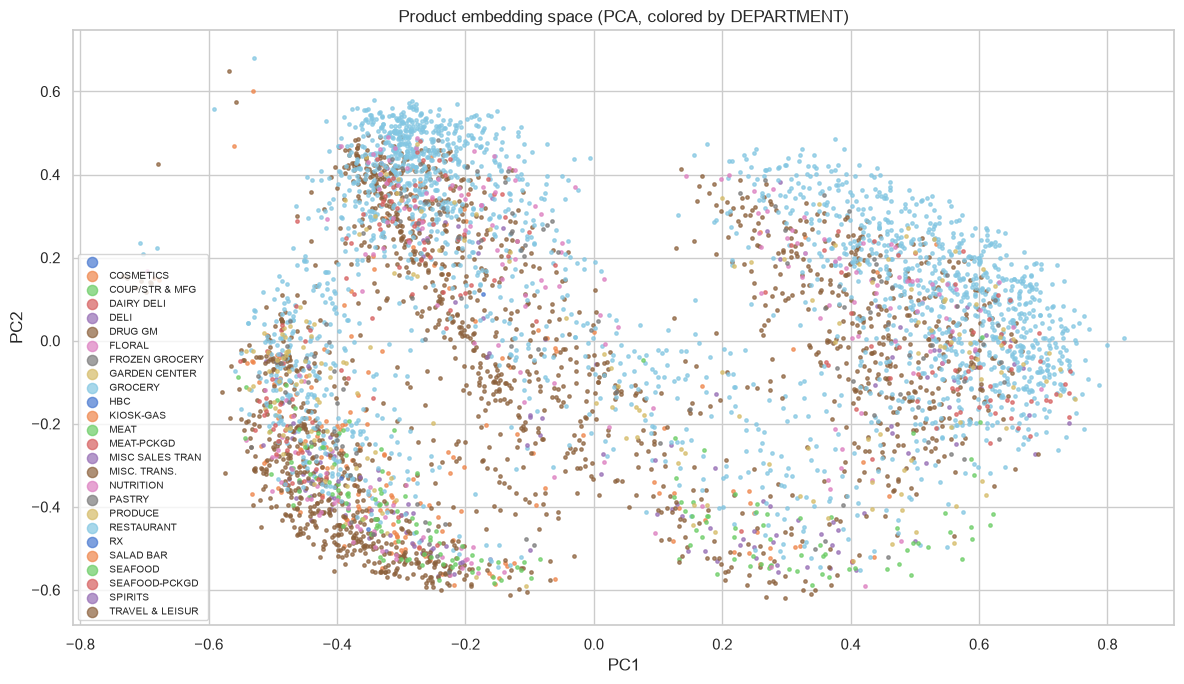

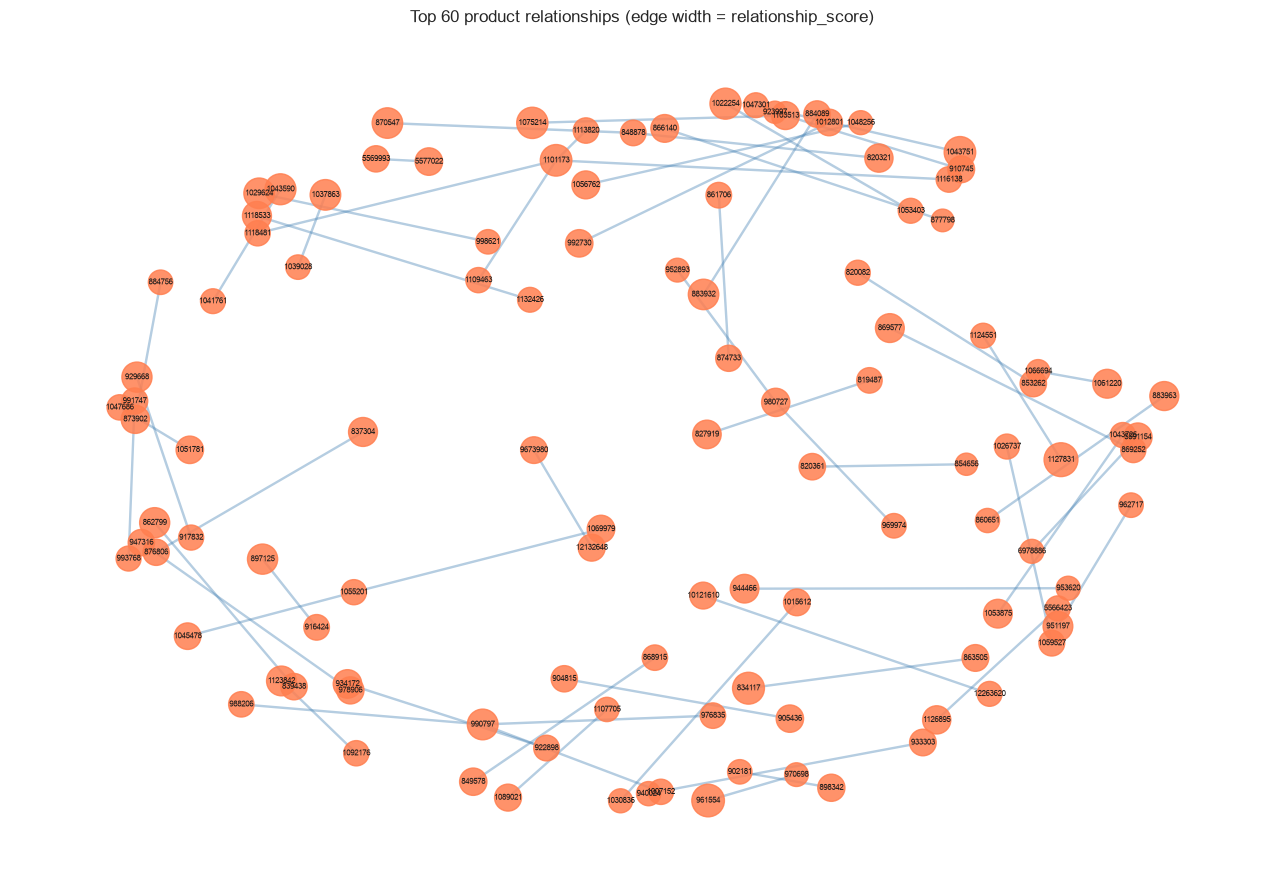

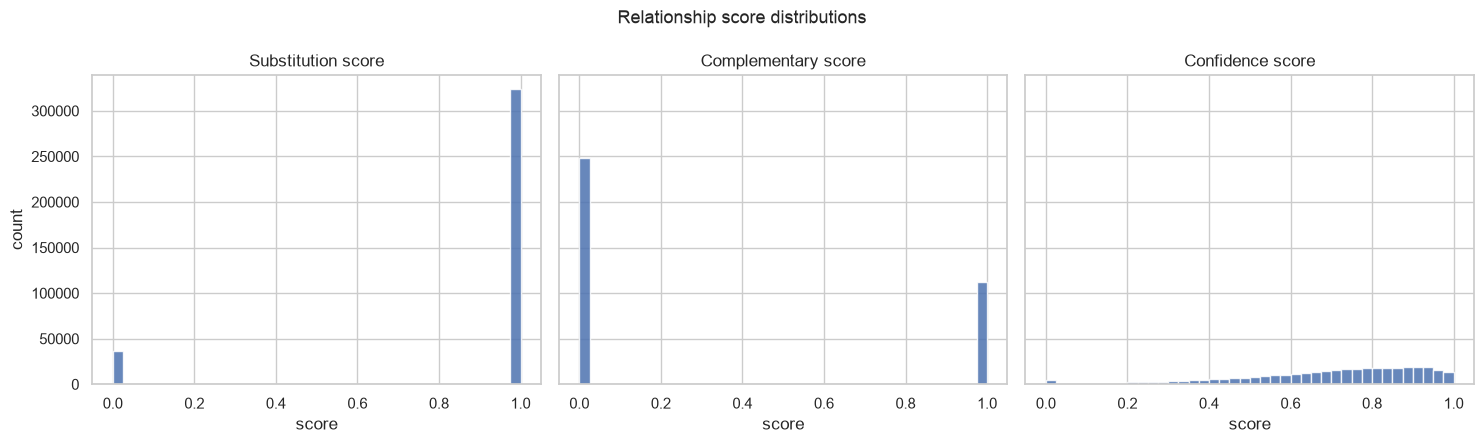

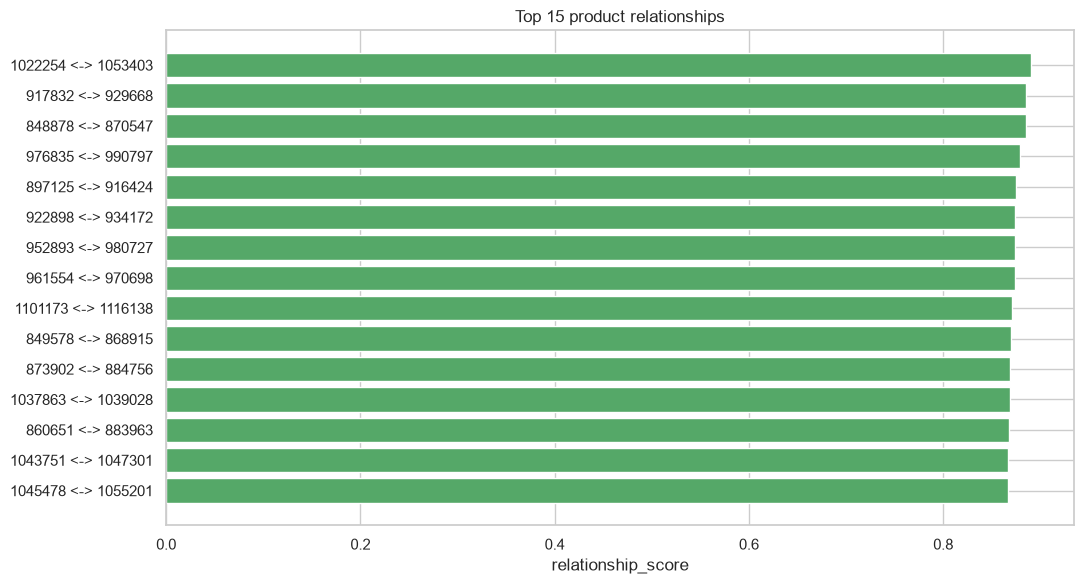

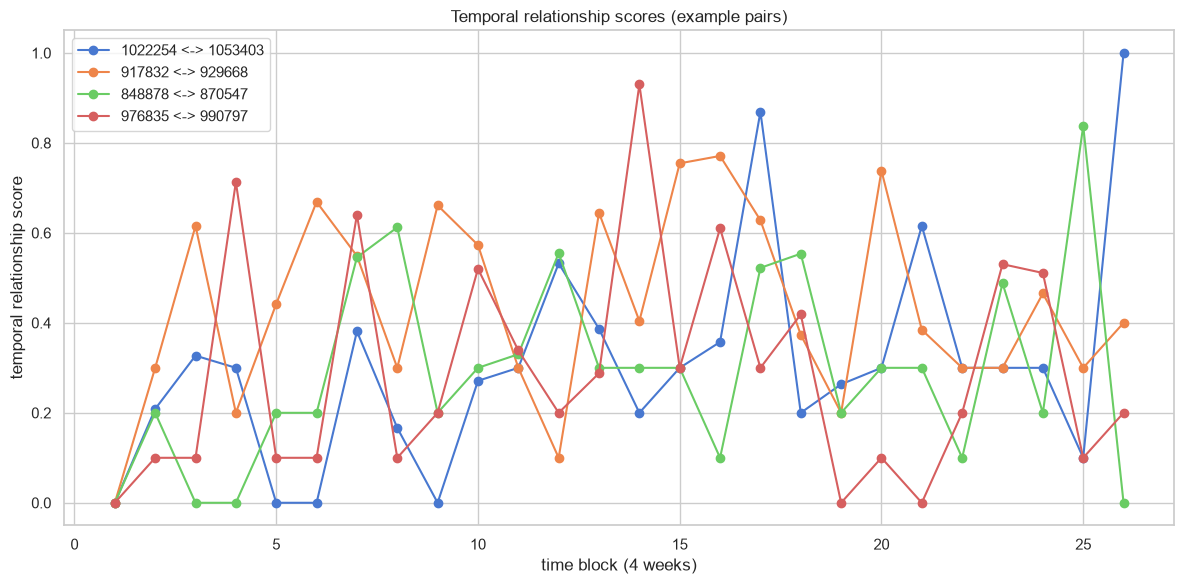

In [45]:
import networkx as nx


def build_dashboard(relationships: pd.DataFrame, embeddings: pd.DataFrame,
                    product_features: pd.DataFrame, temporal: pd.DataFrame) -> None:
    """Render and save the five dashboard figures."""
    meta = product_features.set_index("PRODUCT_ID")
    E = embeddings.set_index("PRODUCT_ID").filter(regex="^emb_").to_numpy()
    ids = embeddings["PRODUCT_ID"].to_numpy()
    rng = np.random.default_rng(CFG.seed)

    # 1) embedding scatter (PCA)
    sample = rng.choice(len(ids), size=min(5000, len(ids)), replace=False)
    xy = PCA(n_components=2, random_state=CFG.seed).fit_transform(E[sample])
    depts = meta.loc[ids[sample], "DEPARTMENT"].to_numpy()
    fig, ax = plt.subplots(figsize=(12, 7))
    for dept in sorted(set(depts)):
        m = depts == dept
        ax.scatter(xy[m, 0], xy[m, 1], s=6, alpha=0.7, label=dept)
    ax.set_title("Product embedding space (PCA, colored by DEPARTMENT)")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(fontsize=7, markerscale=3, loc="best")
    fig.tight_layout()
    fig.savefig(CFG.figures_dir / "dashboard_embedding.png", dpi=110, bbox_inches="tight")
    plt.show()

    # 2) relationship graph (top 60 pairs)
    top = relationships.nlargest(60, "relationship_score")
    G = nx.Graph()
    for _, r in top.iterrows():
        G.add_edge(int(r["product_a"]), int(r["product_b"]),
                   weight=float(r["relationship_score"]))
    sizes = [10 + 60 * np.log1p(meta.loc[n, "total_sales"]) if n in meta.index else 10 for n in G.nodes]
    pos = nx.spring_layout(G, seed=CFG.seed, k=0.5)
    fig, ax = plt.subplots(figsize=(13, 9))
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4,
                           width=[2 * G[u][v]["weight"] for u, v in G.edges()],
                           edge_color="steelblue")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color="coral", alpha=0.85)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=6)
    ax.set_title("Top 60 product relationships (edge width = relationship_score)")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(CFG.figures_dir / "dashboard_graph.png", dpi=110, bbox_inches="tight")
    plt.show()

    # 3) score distributions
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    for ax, col, title in [
        (axes[0], "substitution_score", "Substitution"),
        (axes[1], "complementary_score", "Complementary"),
        (axes[2], "confidence_score", "Confidence"),
    ]:
        ax.hist(relationships[col], bins=40, color="#4C72B0", alpha=0.85)
        ax.set_title(f"{title} score")
        ax.set_xlabel("score")
    axes[0].set_ylabel("count")
    fig.suptitle("Relationship score distributions", fontsize=13)
    fig.tight_layout()
    fig.savefig(CFG.figures_dir / "dashboard_scores.png", dpi=110, bbox_inches="tight")
    plt.show()

    # 4) top related products
    top15 = relationships.nlargest(15, "relationship_score").copy()
    top15["pair"] = top15["product_a"].astype(str) + " <-> " + top15["product_b"].astype(str)
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.barh(top15["pair"], top15["relationship_score"], color="#55A868")
    ax.invert_yaxis()
    ax.set_xlabel("relationship_score")
    ax.set_title("Top 15 product relationships")
    fig.tight_layout()
    fig.savefig(CFG.figures_dir / "dashboard_top_relationships.png", dpi=110, bbox_inches="tight")
    plt.show()

    # 5) temporal relationship plots (4 example pairs)
    pairs = temporal[["product_a", "product_b"]].drop_duplicates().head(4)
    fig, ax = plt.subplots(figsize=(12, 6))
    for _, (a, b) in pairs.iterrows():
        g = temporal[(temporal["product_a"] == a) & (temporal["product_b"] == b)]
        ax.plot(g["block"], g["temporal_score"], marker="o", label=f"{a} <-> {b}")
    ax.set_xlabel("time block (4 weeks)")
    ax.set_ylabel("temporal relationship score")
    ax.set_title("Temporal relationship scores (example pairs)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(CFG.figures_dir / "dashboard_temporal.png", dpi=110, bbox_inches="tight")
    plt.show()


build_dashboard(relationships, embedding_df, product_features, temporal)

In [46]:
# --- validation: dashboard outputs ------------------------------------------
def validate_dashboard(figures_dir: Path) -> None:
    expected = ["embedding_pca.png", "embedding_umap.png", "embedding_clusters.png",
                "shap_confidence.png", "dashboard_embedding.png", "dashboard_graph.png",
                "dashboard_scores.png", "dashboard_top_relationships.png", "dashboard_temporal.png"]
    missing = [f for f in expected if not (figures_dir / f).exists()]
    assert not missing, f"missing figures: {missing}"
    print("PASS: dashboard validated")
    print(f"  figures written to {figures_dir}:")
    for f in expected:
        print(f"    {f}  ({ (figures_dir / f).stat().st_size / 1024:.0f} KB)")


validate_dashboard(CFG.figures_dir)

PASS: dashboard validated
  figures written to /home/mhseddighi/Projects/promotion-intelligence/outputs/product_intelligence/figures:
    embedding_pca.png  (1147 KB)
    embedding_umap.png  (233 KB)
    embedding_clusters.png  (165 KB)
    shap_confidence.png  (144 KB)
    dashboard_embedding.png  (315 KB)
    dashboard_graph.png  (265 KB)
    dashboard_scores.png  (38 KB)
    dashboard_top_relationships.png  (57 KB)
    dashboard_temporal.png  (173 KB)


## 12. Export Production Assets

The pipeline's contract with the rest of the system is a set of versioned artifacts.
This section consolidates the five primary parquet files plus a machine-readable manifest
describing schemas, row counts and production mapping.

In [47]:
# --- consolidate the five primary exports --------------------------------
exports = {
    "product_features.parquet": product_features,
    "product_embeddings.parquet": embedding_df,
    "product_candidates.parquet": candidates,
    "product_pair_features.parquet": pair_features,
    "product_relationships.parquet": relationships,
}
for name, df in exports.items():
    path = CFG.output_dir / name
    df.to_parquet(path, index=False)
    print(f"wrote {path.name:<32} {df.shape}")

manifest = {
    "schema_version": "1.0",
    "generated_at": pd.Timestamp.now().isoformat(),
    "config": {k: (v if isinstance(v, (int, float, str, bool, list, tuple)) else str(v))
               for k, v in vars(CFG).items() if not k.startswith("_")},
    "artifacts": {
        name: {"rows": int(df.shape[0]), "columns": [str(c) for c in df.columns],
               "purpose": purpose}
        for name, purpose in {
            "product_features.parquet": "product catalog representation (feature store)",
            "product_embeddings.parquet": "vector search / similarity service input",
            "product_candidates.parquet": "candidate relationship pairs (recall stage)",
            "product_pair_features.parquet": "relationship feature store",
            "product_relationships.parquet": "ranked substitution/complementary relationships",
        }.items()
        for df in [exports[name]]
    },
    "production_mapping": {
        "backend_api": "GET /products/{id}/related -> reads product_relationships.parquet",
        "ml_pipeline": "retraining / scoring jobs read product_pair_features.parquet",
        "mcp_tools": "explain_relationship -> relationship_explanations.json",
        "llm_analyst": "relationship_explanations.json narratives feed the analyst layer",
    },
}
manifest_path = CFG.output_dir / "pipeline_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print("\nsaved:", manifest_path)

wrote product_features.parquet         (92353, 38)


wrote product_embeddings.parquet       (92353, 129)
wrote product_candidates.parquet       (360524, 3)


wrote product_pair_features.parquet    (360524, 34)
wrote product_relationships.parquet    (360524, 10)

saved: /home/mhseddighi/Projects/promotion-intelligence/outputs/product_intelligence/pipeline_manifest.json


In [48]:
# --- final validation: every export reloads with the expected schema ---------
def validate_exports(output_dir: Path) -> None:
    expected = {
        "product_features.parquet": ["PRODUCT_ID", "total_sales", "n_transactions", "zero_sales_ratio"],
        "product_embeddings.parquet": ["PRODUCT_ID", "emb_0"],
        "product_candidates.parquet": ["product_a", "product_b", "similarity_score"],
        "product_pair_features.parquet": ["product_a", "product_b", "sim_final", "lift", "sales_corr"],
        "product_relationships.parquet": ["product_a", "product_b", "substitution_score",
                                          "complementary_score", "confidence_score",
                                          "relationship_score"],
    }
    summary = []
    for name, required_cols in expected.items():
        path = output_dir / name
        assert path.exists(), f"missing export {name}"
        df = pd.read_parquet(path)
        assert df.shape[0] > 0, f"empty export {name}"
        missing = [c for c in required_cols if c not in df.columns]
        assert not missing, f"{name} missing columns {missing}"
        numeric = df.select_dtypes(include=[np.number])
        assert numeric.isna().sum().sum() == 0, f"{name} has NaN"
        assert np.isfinite(numeric.to_numpy(dtype=np.float64)).all(), f"{name} has Inf"
        summary.append({"artifact": name, "rows": df.shape[0], "columns": df.shape[1],
                        "schema": "OK", "nan/inf": "none"})
    assert (output_dir / "pipeline_manifest.json").exists()
    assert (output_dir / "relationship_explanations.json").exists()
    print("PASS: all exports reloaded and validated")
    print(pd.DataFrame(summary).to_string(index=False))


validate_exports(CFG.output_dir)

PASS: all exports reloaded and validated
                     artifact   rows  columns schema nan/inf
     product_features.parquet  92353       38     OK    none
   product_embeddings.parquet  92353      129     OK    none
   product_candidates.parquet 360524        3     OK    none
product_pair_features.parquet 360524       34     OK    none
product_relationships.parquet 360524       10     OK    none


## Pipeline Summary

The complete v1 pipeline is now executed end-to-end:

```
Dunnhumby raw data
  -> product_features.parquet        (one row per product: metadata + sales + demand)
  -> product_embeddings.parquet      (metadata + behavioral + demand -> final vector)
  -> product_candidates.parquet      (top-k NN pairs, no labels involved)
  -> product_pair_features.parquet   (similarity/customer/basket/sales/price/promo/temporal)
  -> product_relationships.parquet   (substitution, complementary, confidence scores)
  + relationship_explanations.json   (MCP-ready evidence)
  + temporal_relationships.parquet   (drift monitoring)
  + pipeline_manifest.json           (schema + production mapping)
```

### Production roadmap (from this notebook)

1. **DataLoader service** — reuse the typed loaders + schema validation.
2. **Vectorization service** — versioned embedding builders; cosine search over the vector
   store; the same quality gates run before promotion.
3. **Candidate service** — FAISS recall stage, configurable `top_k`/`min_similarity`.
4. **Relationship scoring service** — GMM + IsolationForest scoring functions extracted
   verbatim; scores re-generated on a schedule and cached.
5. **Explainability MCP tool** — serve `relationship_explanations.json` as
   `explain_relationship(product_a, product_b)` for the LLM analyst layer.
6. **Drift monitor** — temporal blocks + drift labels alert when relationships change.

### Next steps

- Backtest candidate recall against known category mappings (evaluation, not labels).
- Add a lightweight supervised calibration layer once merchant-labeled relationships exist.
- Scale candidate generation with HNSW/IVF FAISS indices.
- Add A/B evaluation of embedding versions before promotion to the vector store.